<div style="box-sizing:border-box;width:100%;margin:12px 0 28px;padding:38px 40px;border:1px solid rgba(255,255,255,.14);border-radius:22px;background:radial-gradient(circle at 92% 10%,rgba(255,255,255,.14) 0 7%,transparent 8%),linear-gradient(125deg,#0b1f3a 0%,#164e63 58%,#0f9d91 100%);color:#ffffff;font-family:Inter,'Segoe UI',Arial,sans-serif;box-shadow:0 14px 35px rgba(16,42,67,.24);overflow:hidden;">
  <div style="display:inline-block;margin:0 0 15px;padding:7px 13px;border:1px solid rgba(255,255,255,.30);border-radius:999px;background:rgba(255,255,255,.13);color:#ffffff;font-size:11px;font-weight:800;line-height:1.2;letter-spacing:.07em;text-transform:uppercase;">Avance reproducible · 75%</div>
  <div style="margin:0 0 7px;color:#ffffff;font-size:38px;font-weight:800;line-height:1.15;letter-spacing:-.02em;">Laboratorio 5</div>
  <div style="margin:0 0 12px;color:rgba(255,255,255,.93);font-size:21px;font-weight:500;line-height:1.4;">Minería de Textos y Análisis de Sentimientos</div>
  <div style="max-width:880px;margin:0;color:rgba(255,255,255,.80);font-size:15px;line-height:1.65;">Clasificación de tweets sobre desastres reales mediante NLP y aprendizaje automático.</div>
  <div style="width:72px;height:4px;margin:22px 0;background:linear-gradient(90deg,#f59e0b,rgba(255,255,255,.85));border-radius:999px;"></div>
  <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(210px,1fr));gap:11px;margin:0;">
    <div style="min-width:0;padding:14px 16px;border:1px solid rgba(255,255,255,.23);border-radius:12px;background:rgba(255,255,255,.09);color:#ffffff;font-size:13px;line-height:1.5;">
      <span style="display:block;margin-bottom:4px;color:#ffffff;font-size:13px;font-weight:750;">Jorge Gabriel Palacios Sales</span>
      <span style="color:rgba(255,255,255,.68);font-size:12px;font-weight:600;">Carné 231385</span>
    </div>
    <div style="min-width:0;padding:14px 16px;border:1px solid rgba(255,255,255,.23);border-radius:12px;background:rgba(255,255,255,.09);color:#ffffff;font-size:13px;line-height:1.5;">
      <span style="display:block;margin-bottom:4px;color:#ffffff;font-size:13px;font-weight:750;">Pablo Daniel Barillas Moreno</span>
      <span style="color:rgba(255,255,255,.68);font-size:12px;font-weight:600;">Carné 22193</span>
    </div>
    <div style="min-width:0;padding:14px 16px;border:1px solid rgba(255,255,255,.23);border-radius:12px;background:rgba(255,255,255,.09);color:#ffffff;font-size:13px;line-height:1.5;">
      <span style="display:block;margin-bottom:4px;color:#ffffff;font-size:13px;font-weight:750;">Roberto Emiliano Otoniel</span>
      <span style="color:rgba(255,255,255,.68);font-size:12px;font-weight:600;">Carné 23968</span>
    </div>
  </div>
  <div style="display:flex;flex-wrap:wrap;gap:8px 18px;margin-top:22px;padding-top:17px;border-top:1px solid rgba(255,255,255,.20);color:rgba(255,255,255,.78);font-size:12px;line-height:1.5;">
    <span style="color:#ffffff;font-weight:750;">Universidad del Valle de Guatemala</span>
    <span>Data Science</span>
    <span>Sección 10</span>
    <span>Grupo 1</span>
  </div>
</div>

<div class="section"><h2>1 · Alcance y reproducibilidad</h2></div>

Este avance cubre la descripción de los datos, limpieza explicada, exploración, probabilidades de unigramas, bigramas y trigramas, comparación preliminar de modelos, función de inferencia y una primera lectura de sentimiento. Todas las cifras que se muestran provienen de los artefactos generados por `scripts/run_advance.py`; no se escribieron manualmente en el notebook.

In [3]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Image, display
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "train.csv").exists():
    ROOT = ROOT.parent

TABLES = ROOT / "outputs" / "tables"
FIGURES = ROOT / "outputs" / "figures"

# CSS también incrustado desde código para conservar el estilo en ejecución.
display(HTML(
    "<style>"
    ".metric-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin:14px 0}"
    ".metric{padding:16px;border-radius:14px;background:#f8fbff;border:1px solid #d8e6f5;text-align:center}"
    ".metric b{display:block;font-size:1.55rem;color:#2563eb}.ok{color:#047857;font-weight:700}"
    "</style>"
))
print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: c:\Users\max75\OneDrive\Escritorio\lab5\Laboratorio-5.-Mineria-de-Textos-y-Analisis-de-Sentimientos_Grupo-1_DS_Sec-10


<div class="section"><h2>2 · Datos y análisis exploratorio</h2></div>

,target,tweets,categoria,porcentaje
0,0,4342,No desastre,57.03%
1,1,3271,Desastre real,42.97%


,variable,tipo,faltantes,faltantes_pct,valores_unicos
0,id,int64,0,0.000000,7613
1,keyword,str,61,0.801261,221
2,location,str,2533,33.272035,3341
3,text,str,0,0.000000,7503
4,target,int64,0,0.000000,2
5,clean_text,str,0,0.000000,6772
6,char_count,int64,0,0.000000,147
7,word_count,int64,0,0.000000,31
8,clean_word_count,int64,0,0.000000,22
9,unique_word_ratio,float64,0,0.000000,97


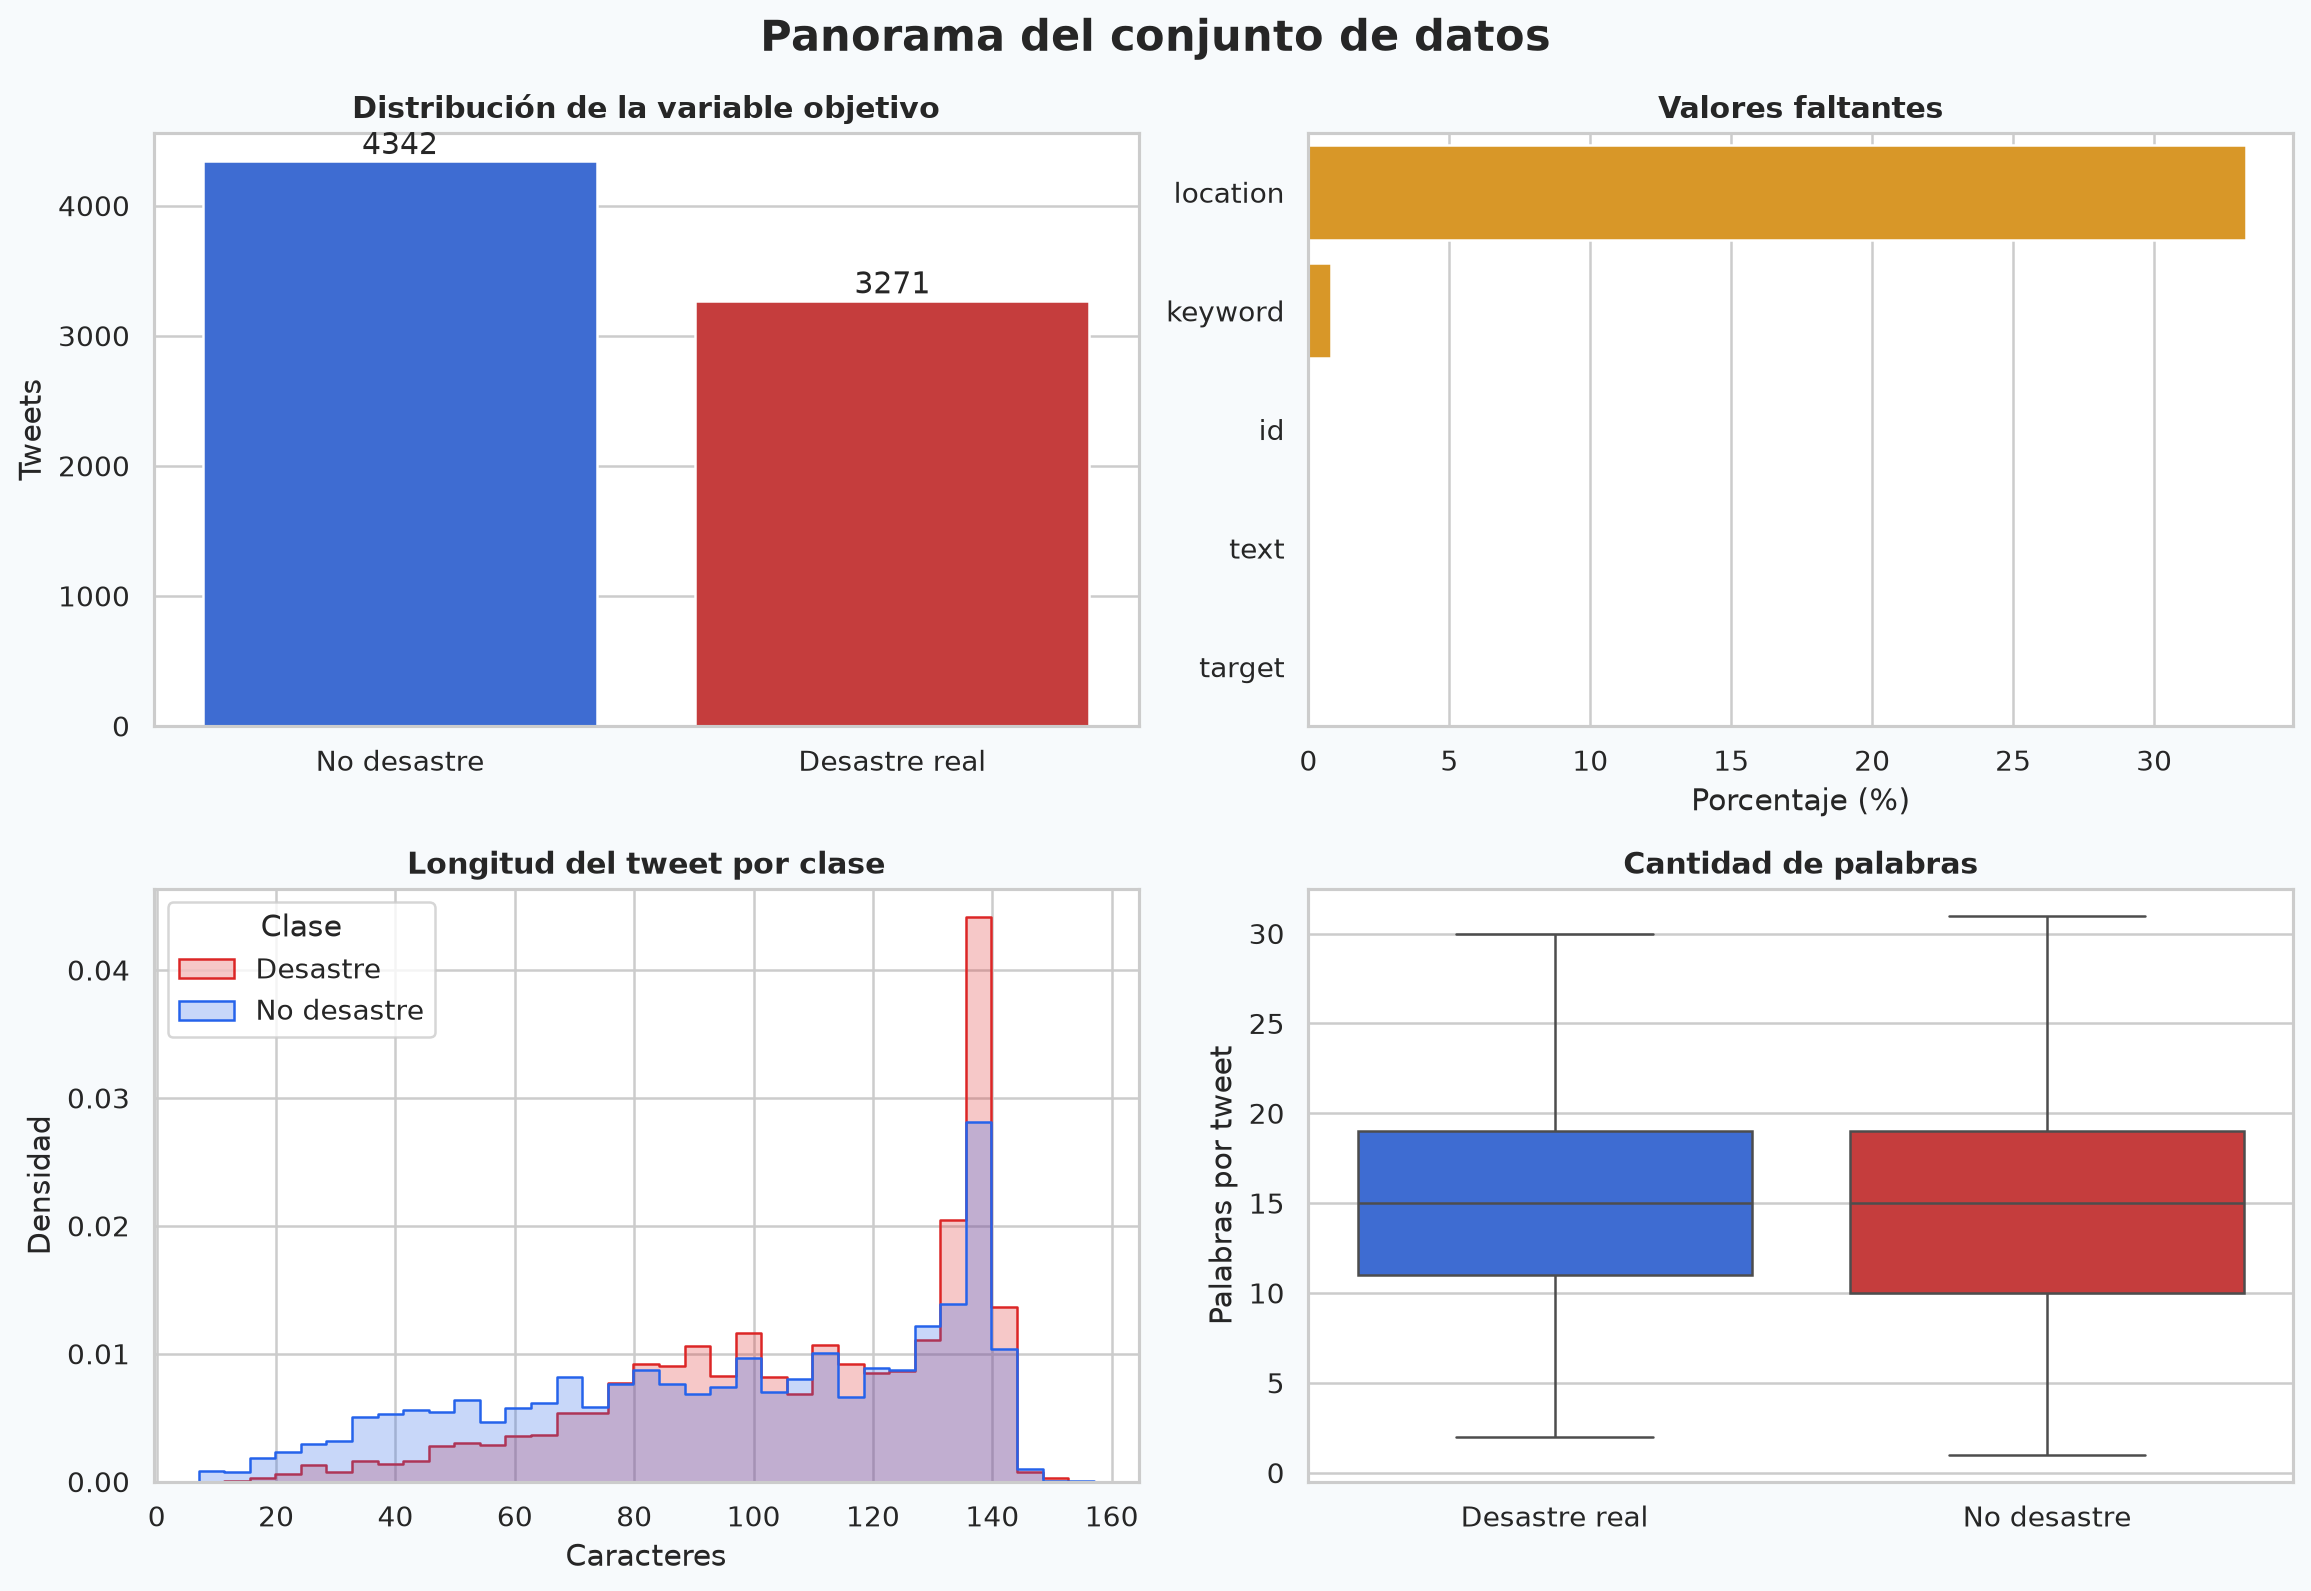

In [4]:
distribution = pd.read_csv(TABLES / "distribucion_target.csv")
schema = pd.read_csv(TABLES / "dataset_esquema.csv")
display(HTML("<h3>Distribución de la variable objetivo</h3>"))
display(distribution.style.format({"porcentaje": "{:.2f}%"}))
display(HTML("<h3>Esquema y valores faltantes</h3>"))
display(schema)
display(Image(filename=str(FIGURES / "eda_panorama.png"), width=1050))

El corpus contiene **7,613 tweets**: 4,342 (57.03%) no describen un desastre real y 3,271 (42.97%) sí. El desbalance es moderado, por lo que se usa partición estratificada y se reportan F1, recall, F1 macro y ROC-AUC además de exactitud. `location` es principalmente un campo auxiliar: su ausencia no impide explotar el texto.

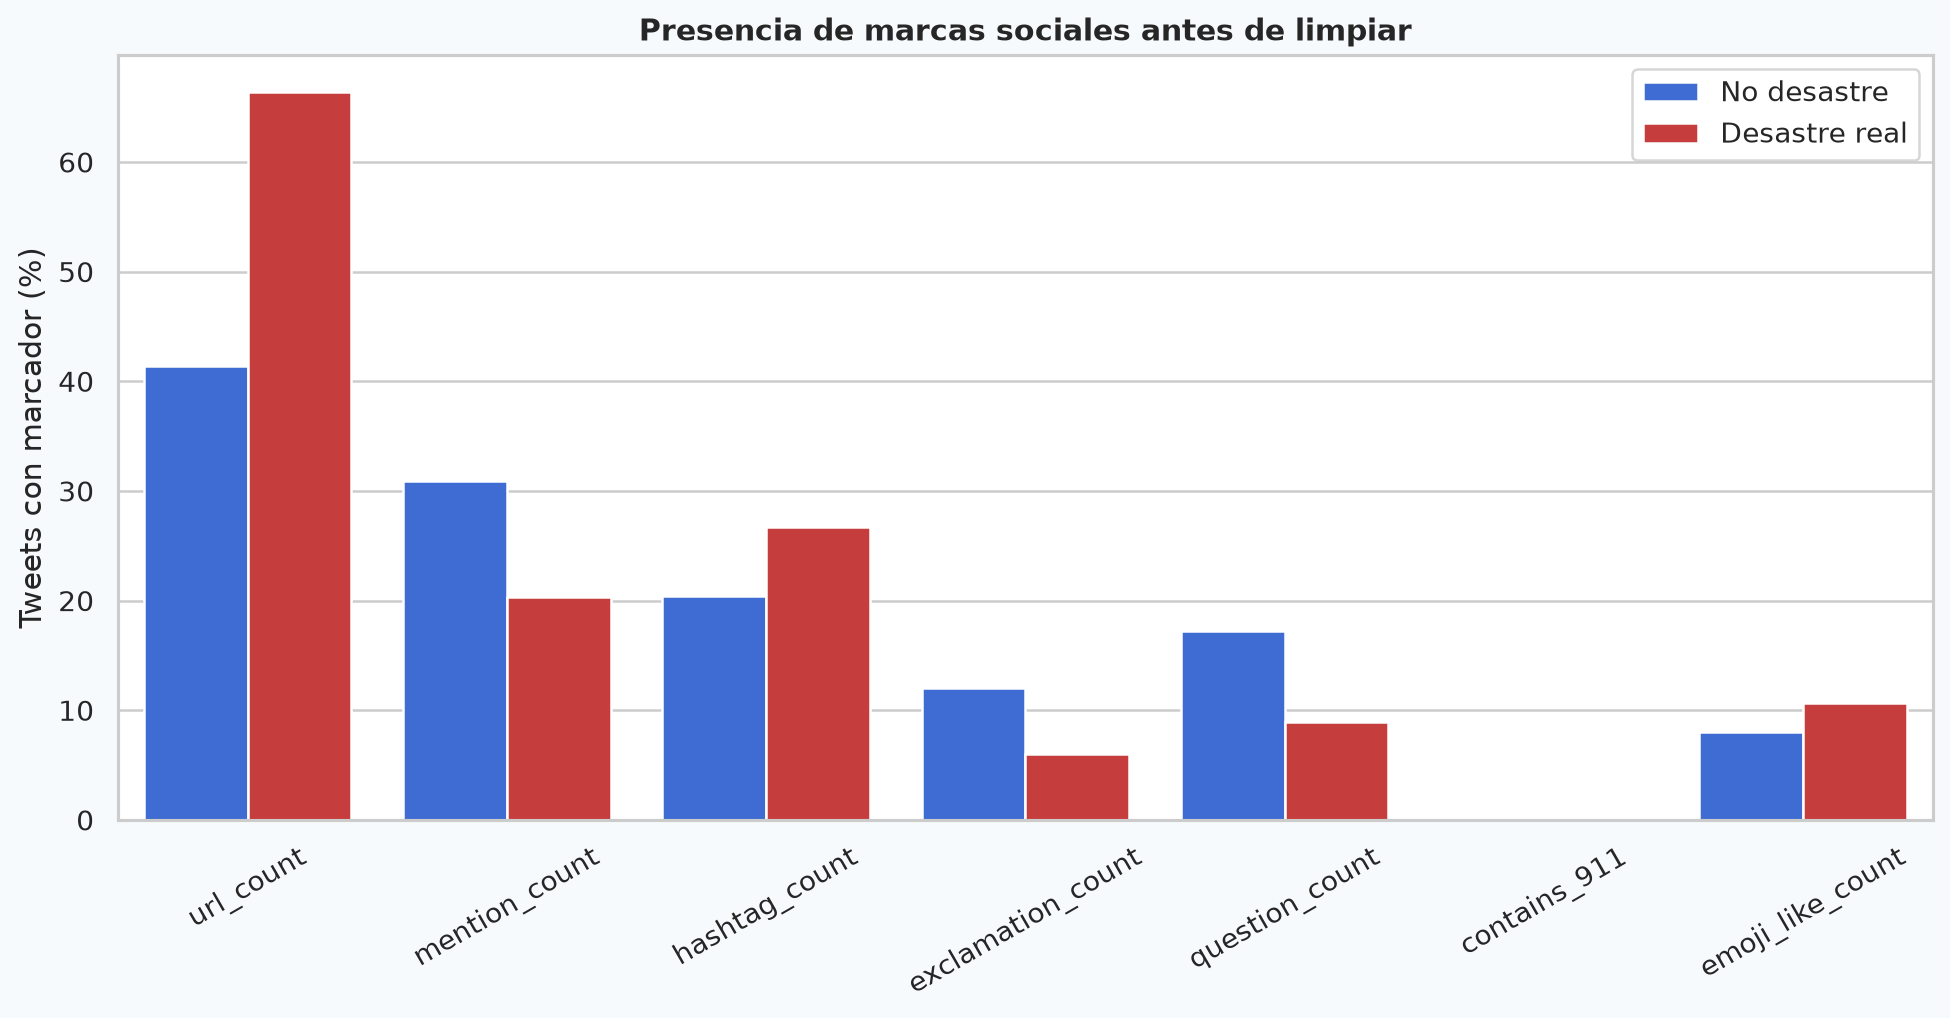

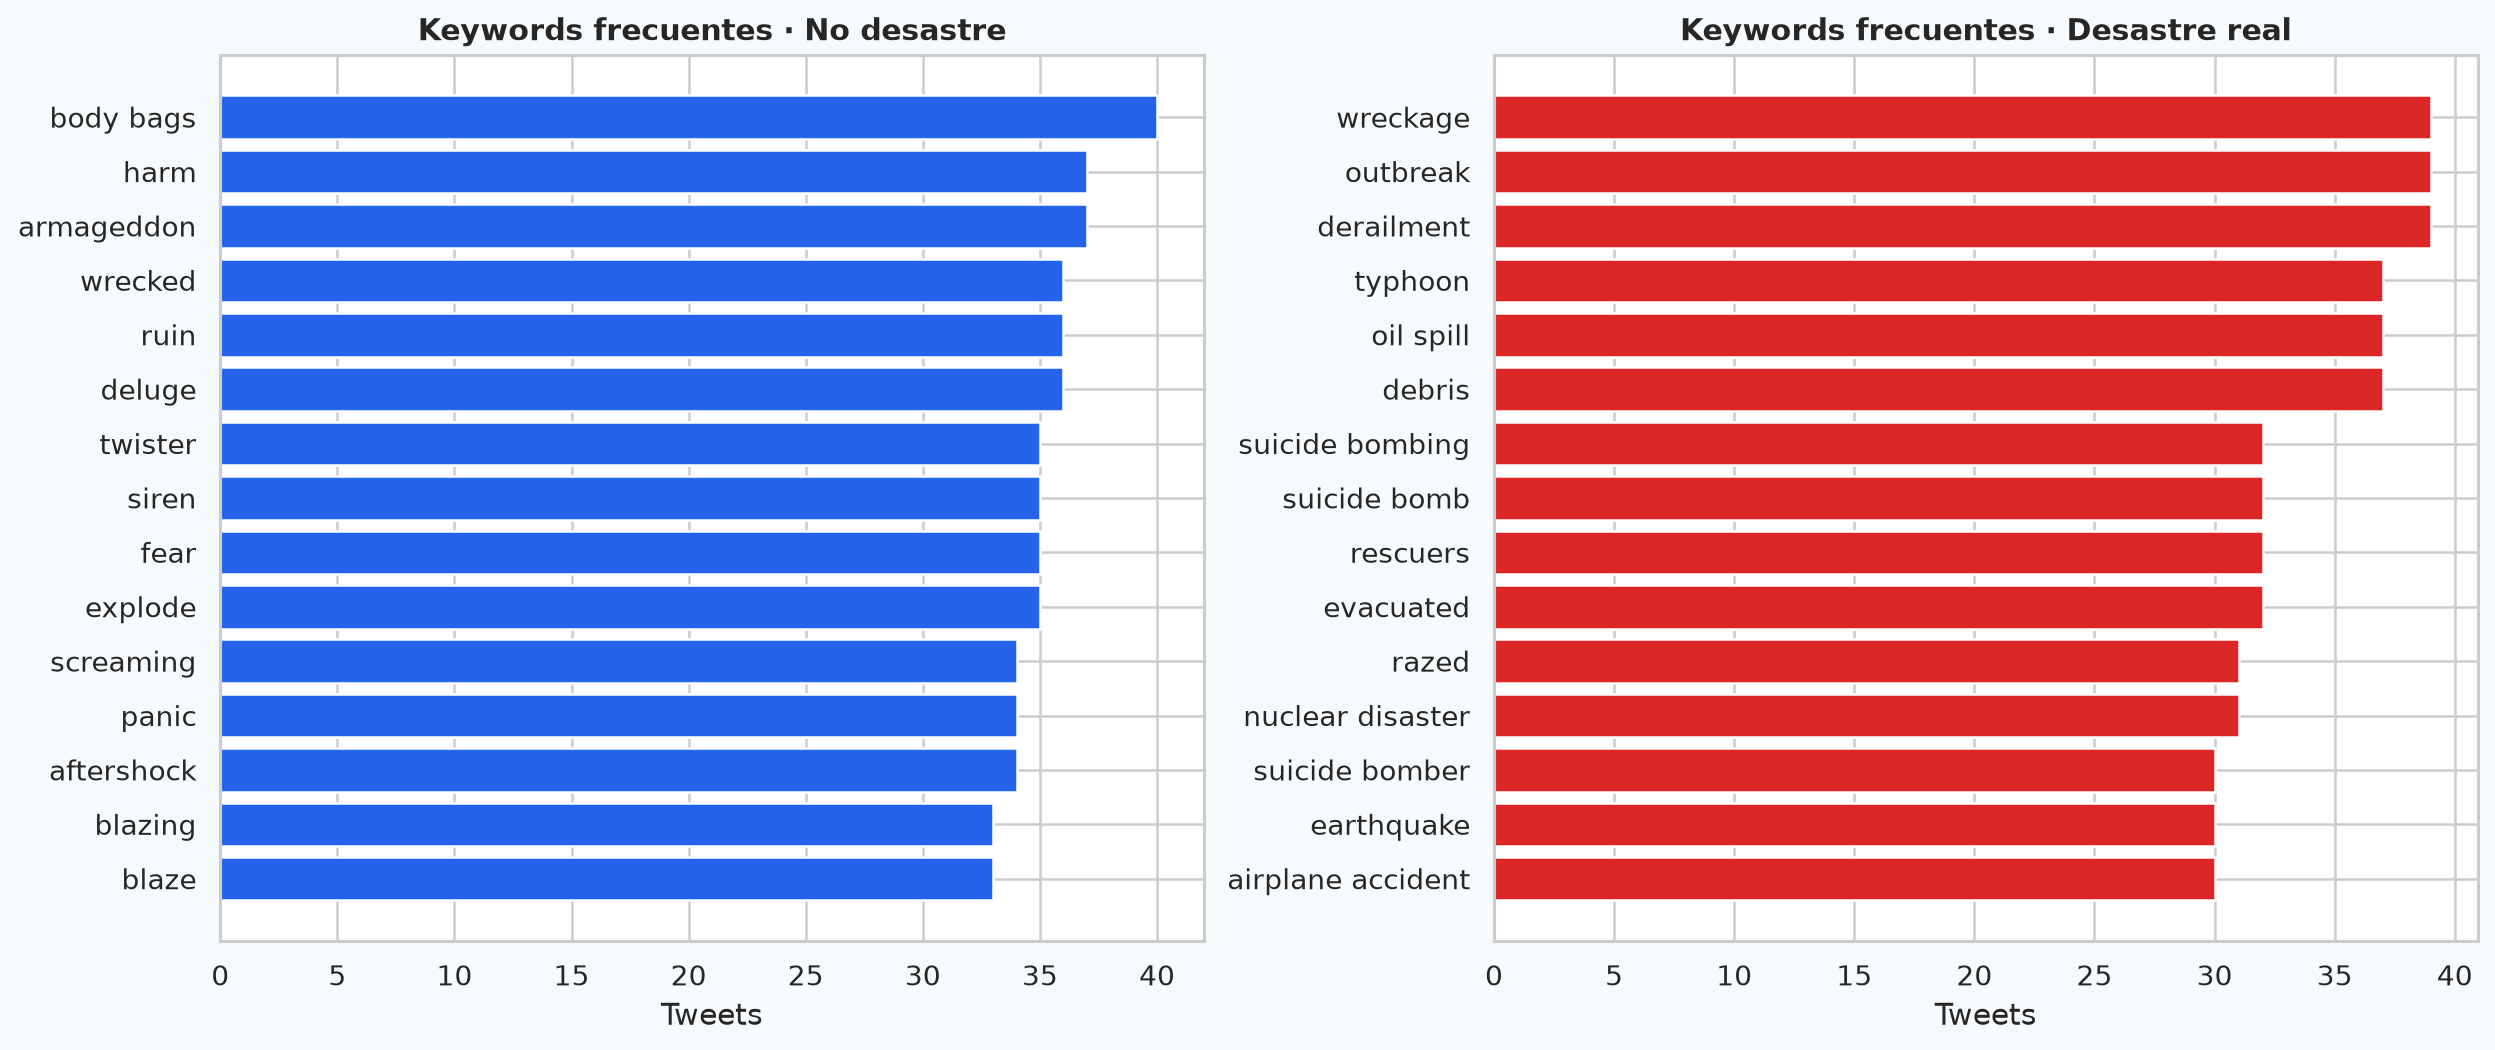

In [5]:
display(Image(filename=str(FIGURES / "eda_marcadores_sociales.png"), width=1000))
display(Image(filename=str(FIGURES / "eda_keywords.png"), width=1000))

<div class="section"><h2>3 · Preprocesamiento auditable</h2></div>

Se crean dos representaciones con propósitos distintos:

1. **Clasificación:** minúsculas, contracciones expandidas, eliminación de URL y menciones, conservación de la palabra del hashtag, eliminación de puntuación/dígitos y stopwords. Las negaciones (`no`, `not`, `never`) y el token `911` se preservan porque tienen información semántica.
2. **Sentimiento:** limpieza ligera; conserva puntuación, emojis y negaciones para no borrar señales afectivas que VADER necesita.

Esta separación evita el error metodológico de calcular sentimiento sobre texto excesivamente depurado.

In [6]:
examples = pd.read_csv(TABLES / "ejemplos_preprocesamiento.csv")
audit = pd.read_csv(TABLES / "auditoria_limpieza.csv")
display(examples[["target", "text", "clean_text"]].head(8))
display(HTML("<h3>Controles automáticos de limpieza</h3>"))
display(audit)

,target,text,clean_text
0,1,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake allah forgive
1,1,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
2,1,Just got sent this photo from Ruby #Alaska as ...,just got sent photo ruby alaska smoke wildfire...
3,1,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
4,1,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
5,1,Haha South Tampa is getting flooded hah- WAIT ...,haha south tampa getting flooded hah wait seco...
6,1,#raining #flooding #Florida #TampaBay #Tampa 1...,raining flooding florida tampabay tampa days l...
7,1,#Flood in Bago Myanmar #We arrived Bago,flood bago myanmar arrived bago


,indicador,valor
0,tweets_totales,7613.000000
1,texto_original_vacio,0.000000
2,texto_limpio_vacio,5.000000
3,palabras_original_promedio,14.903586
4,palabras_limpias_promedio,8.185472
5,tweets_con_url,3971.000000
6,tweets_con_mencion,2009.000000
7,tweets_con_hashtag,1761.000000
8,tweets_con_911,4.000000
9,texto_limpio_con_911,4.000000


<div class="section"><h2>4 · N-gramas y probabilidades</h2></div>

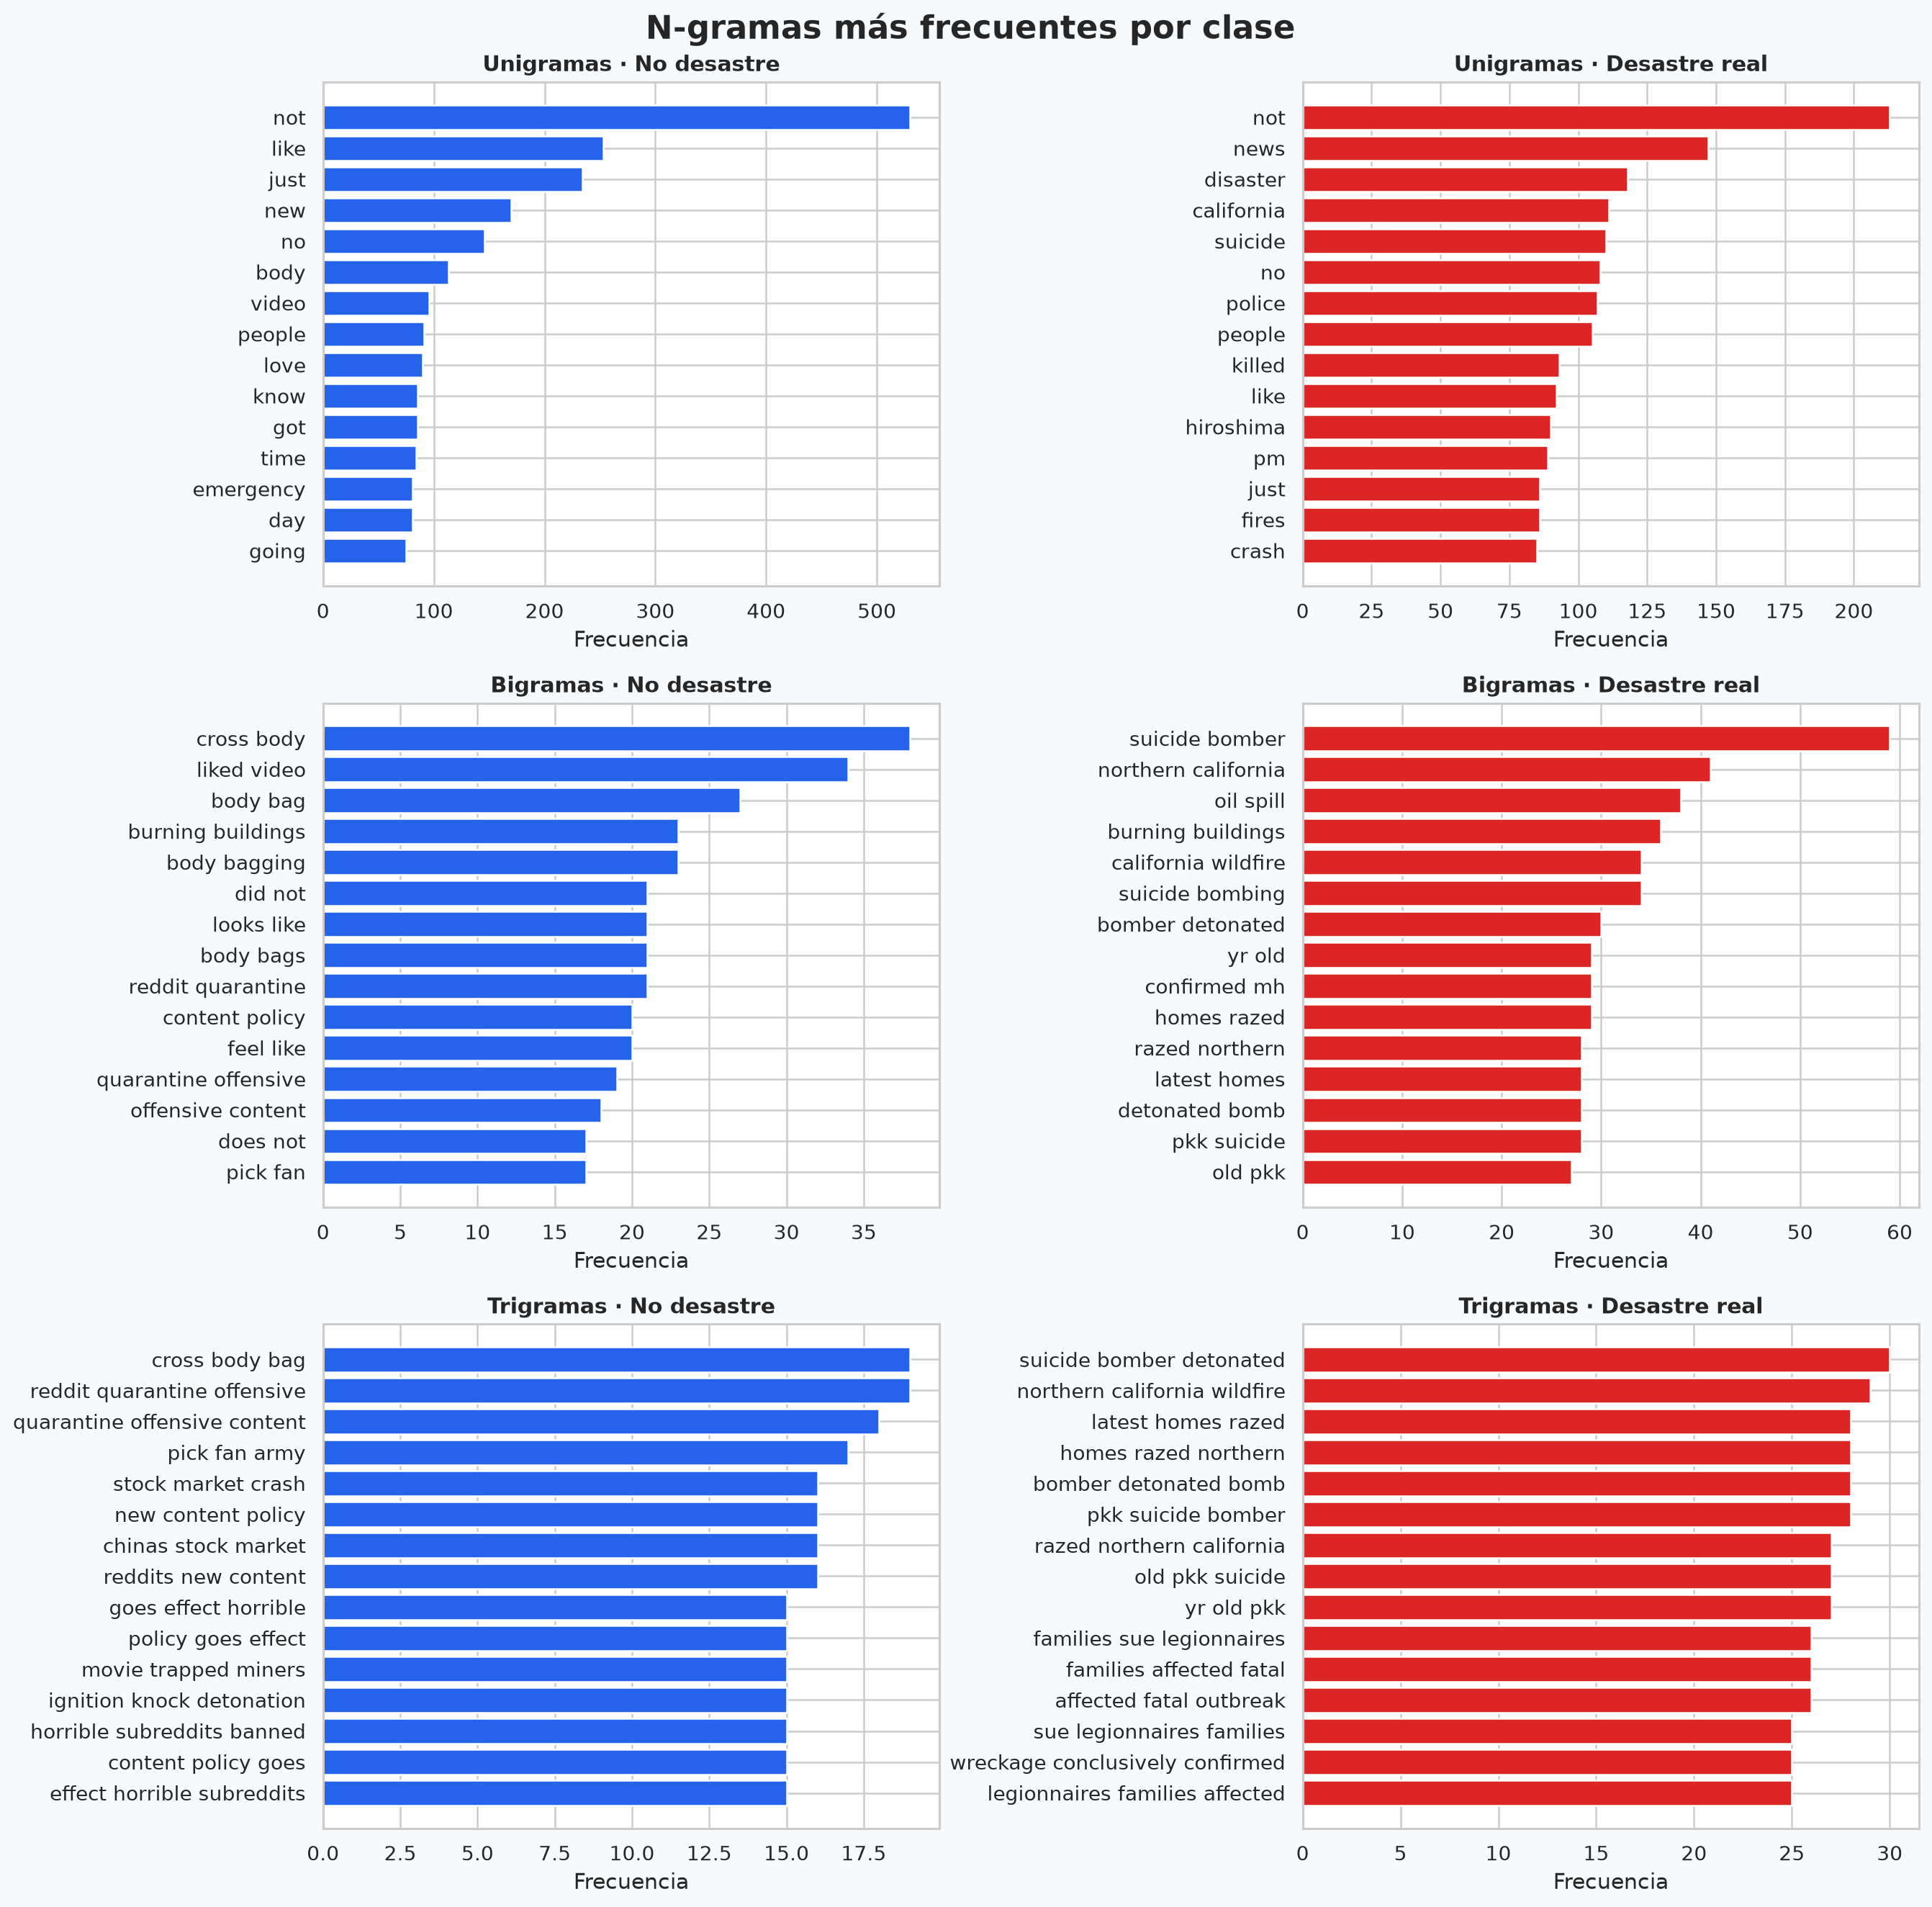

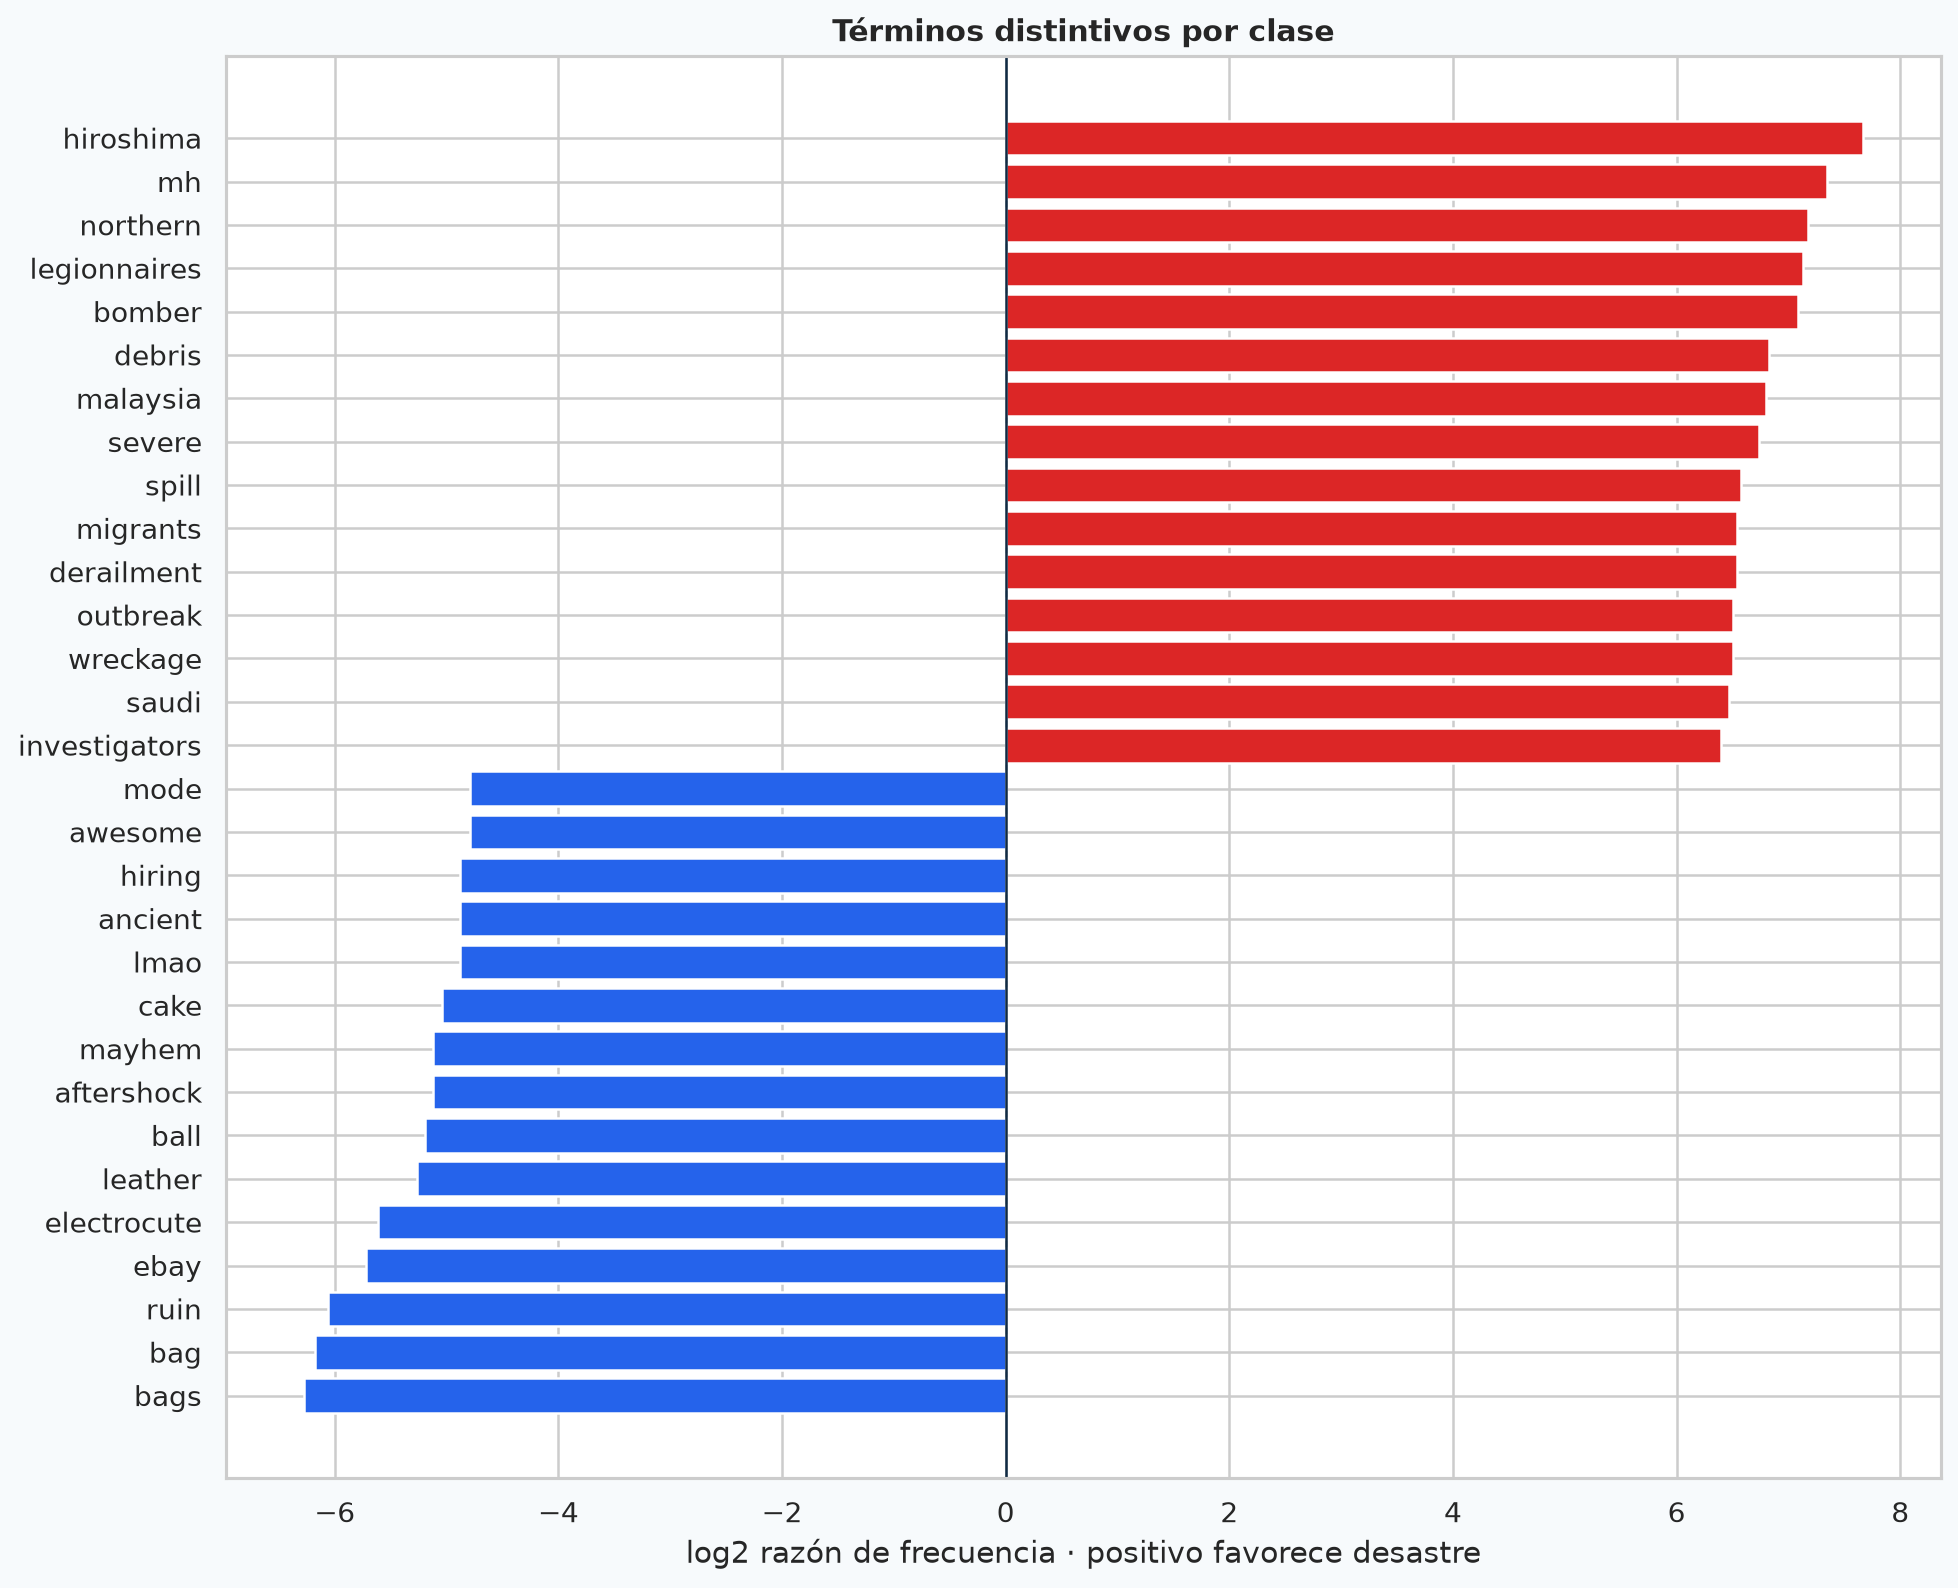

In [7]:
display(Image(filename=str(FIGURES / "ngramas_por_clase.png"), width=1100))
display(Image(filename=str(FIGURES / "unigramas_distintivos.png"), width=1000))

Para cada clase y orden (n), la probabilidad empírica se calcula como

\[
P(g\mid c)=\frac{f(g,c)}{\sum_{g'}f(g',c)}.
\]

No se confunde frecuencia bruta con probabilidad: ambos valores están disponibles en los CSV. Los bigramas como *suicide bomber*, *oil spill* y *northern california* concentran contexto más específico para desastre que palabras aisladas. El cociente logarítmico suavizado complementa el ranking y señala vocabulario distintivo de cada clase.

,ngram,frecuencia,probabilidad,n,target
0,cross body,38,0.5843%,2,0
1,liked video,34,0.5228%,2,0
2,body bag,27,0.4152%,2,0
3,body bagging,23,0.3537%,2,0
4,burning buildings,23,0.3537%,2,0
5,reddit quarantine,21,0.3229%,2,0
6,body bags,21,0.3229%,2,0
7,looks like,21,0.3229%,2,0
8,did not,21,0.3229%,2,0
9,feel like,20,0.3076%,2,0


,ngram,frecuencia,probabilidad,n,target
0,suicide bomber,59,0.5893%,2,1
1,northern california,41,0.4095%,2,1
2,oil spill,38,0.3795%,2,1
3,burning buildings,36,0.3596%,2,1
4,suicide bombing,34,0.3396%,2,1
5,california wildfire,34,0.3396%,2,1
6,bomber detonated,30,0.2996%,2,1
7,homes razed,29,0.2897%,2,1
8,confirmed mh,29,0.2897%,2,1
9,yr old,29,0.2897%,2,1


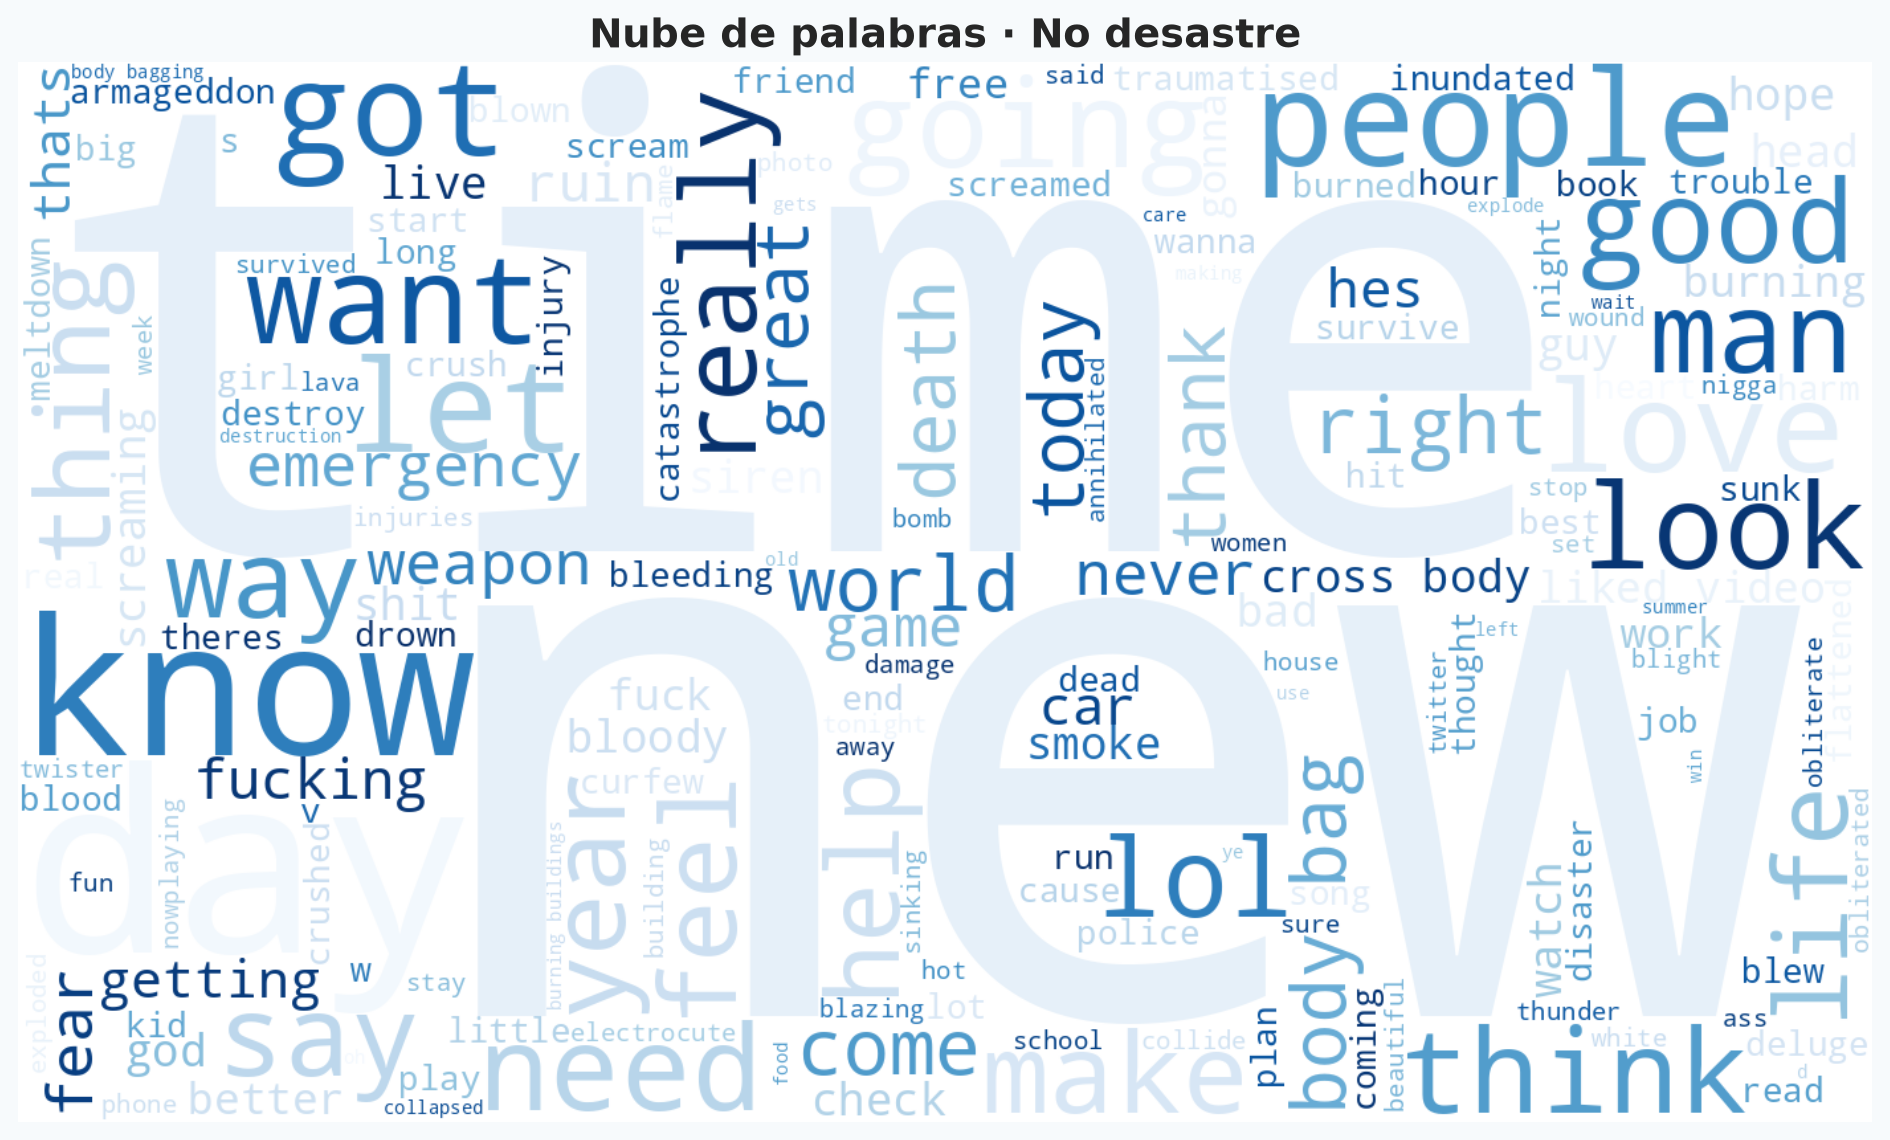

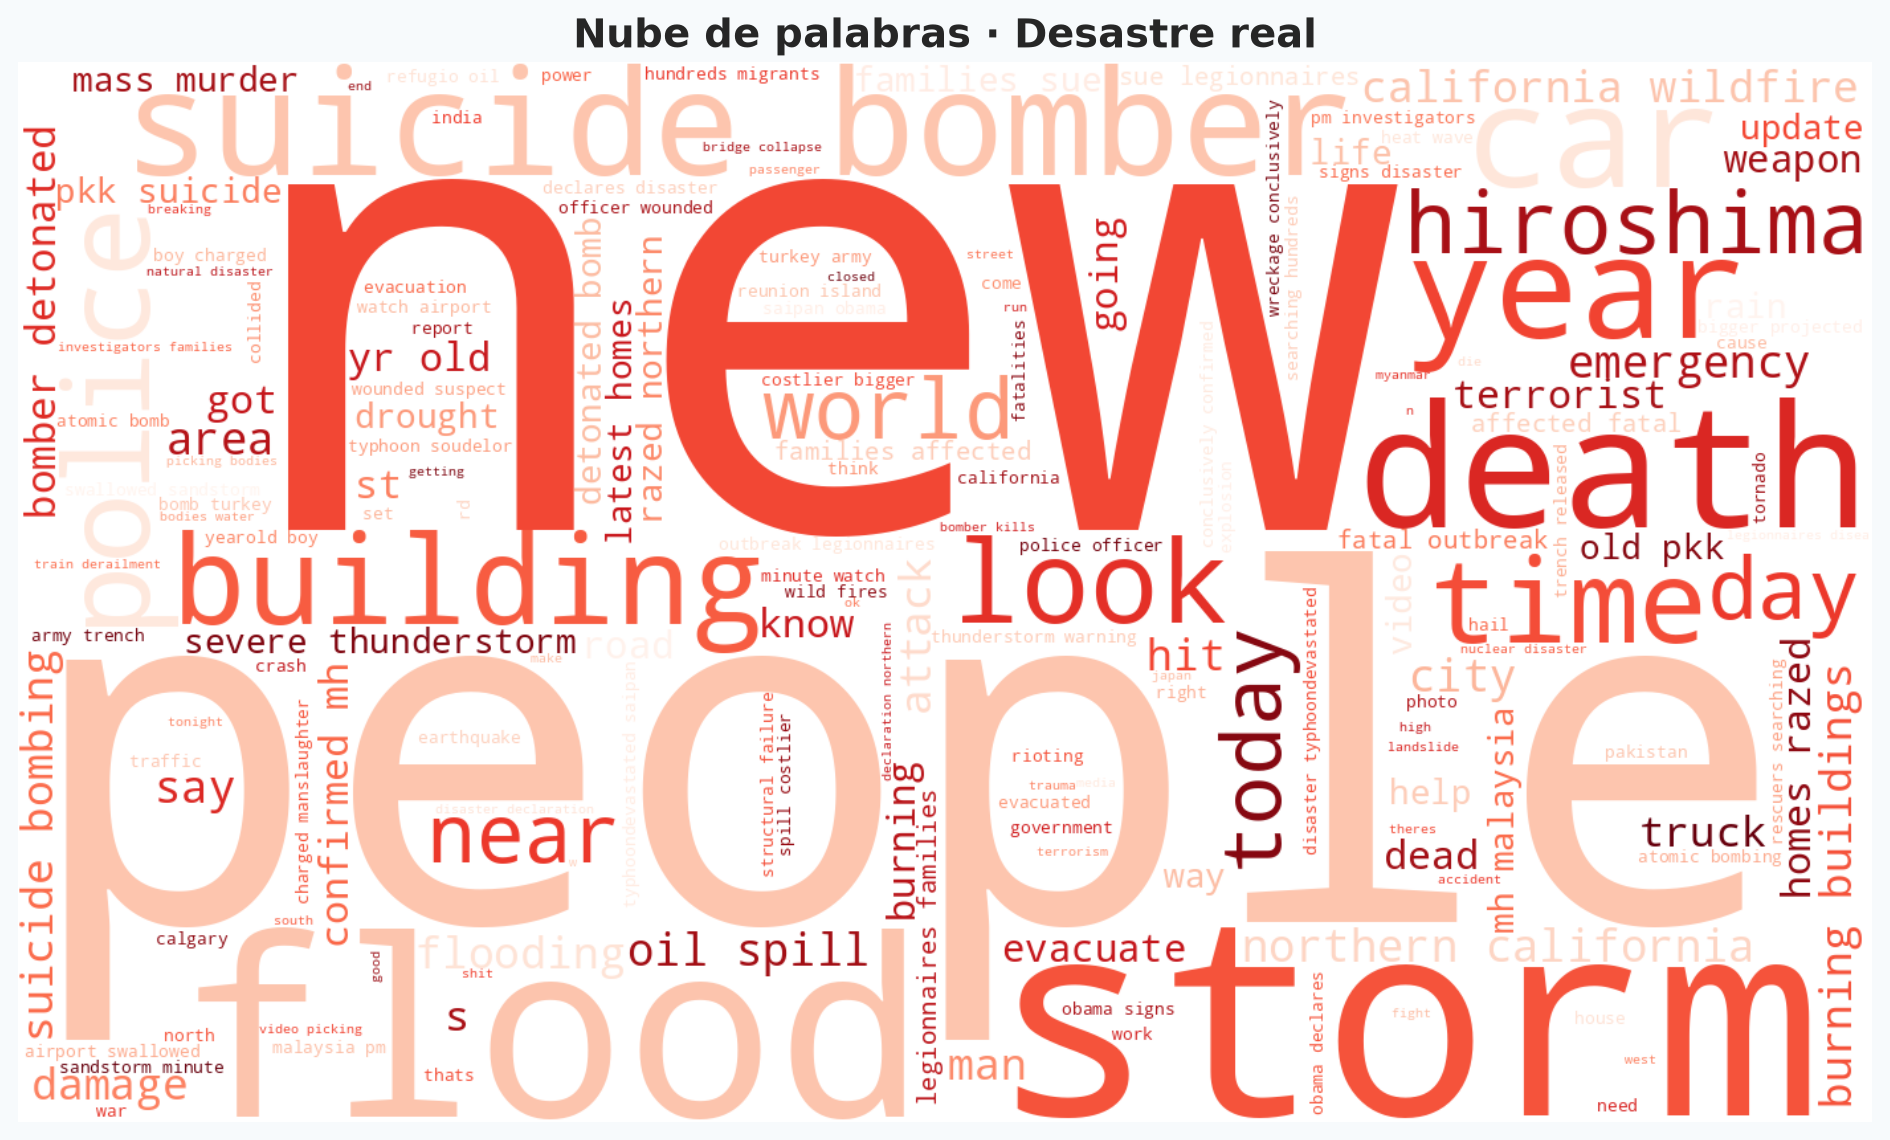

In [8]:
for target, label in [(0, "No desastre"), (1, "Desastre real")]:
    table = pd.read_csv(TABLES / f"bigramas_target_{target}.csv").head(10)
    display(HTML(f"<h3>{label}: diez bigramas principales</h3>"))
    display(table.style.format({"probabilidad": "{:.4%}"}))

display(Image(filename=str(FIGURES / "nube_palabras_target_0.png"), width=850))
display(Image(filename=str(FIGURES / "nube_palabras_target_1.png"), width=850))

<div class="section"><h2>5 · Modelos preliminares</h2></div>

,modelo,accuracy,precision,recall,f1,f1_macro,roc_auc,tn,fp,fn,tp,n_train,n_test
0,Regresión logística,0.813,0.785,0.777,0.781,0.809,0.867,730,139,146,508,6090,1523
1,SVM lineal calibrado,0.810,0.807,0.731,0.767,0.803,0.861,755,114,176,478,6090,1523
2,Naive Bayes complementario,0.807,0.800,0.734,0.766,0.801,0.864,749,120,174,480,6090,1523
3,Baseline mayoritaria,0.571,0.000,0.000,0.000,0.363,0.500,869,0,654,0,6090,1523


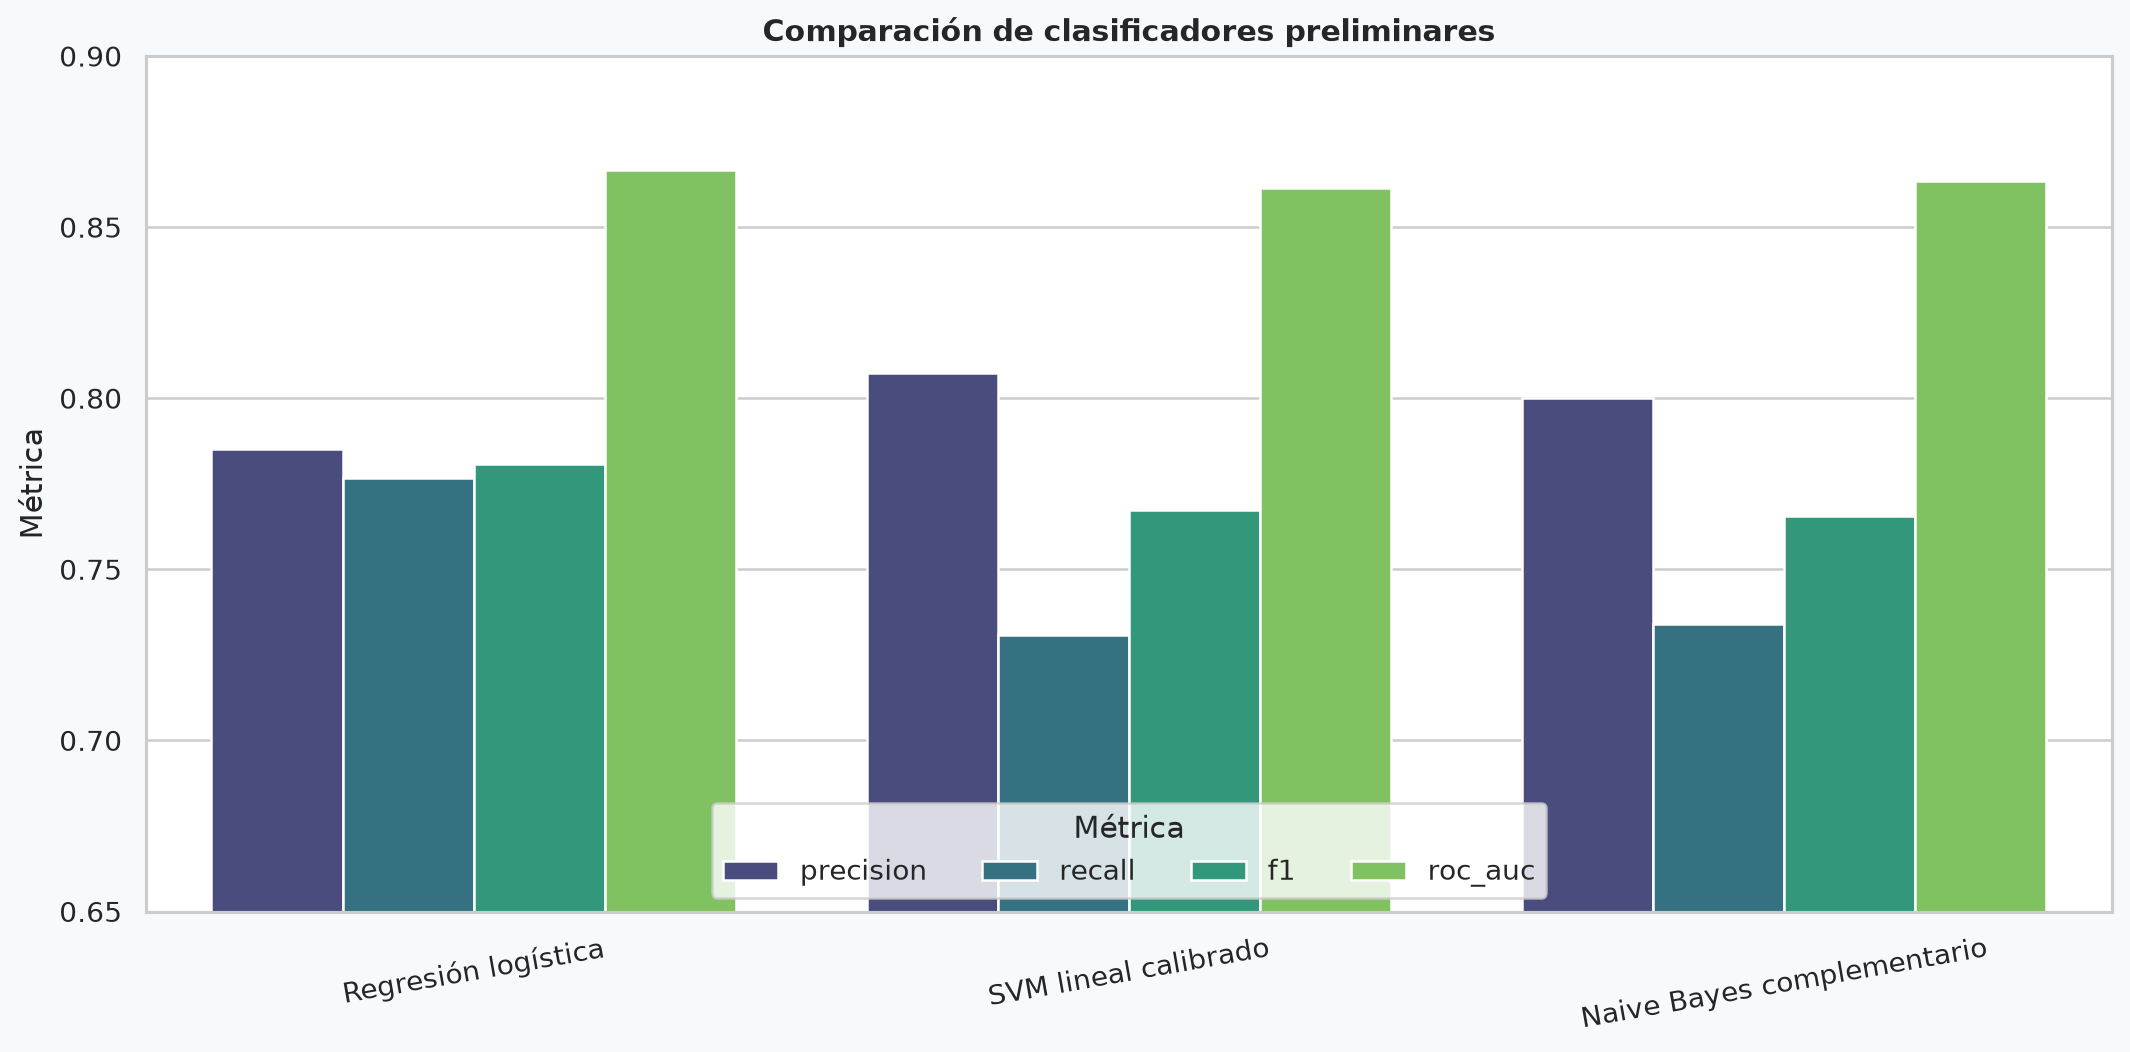

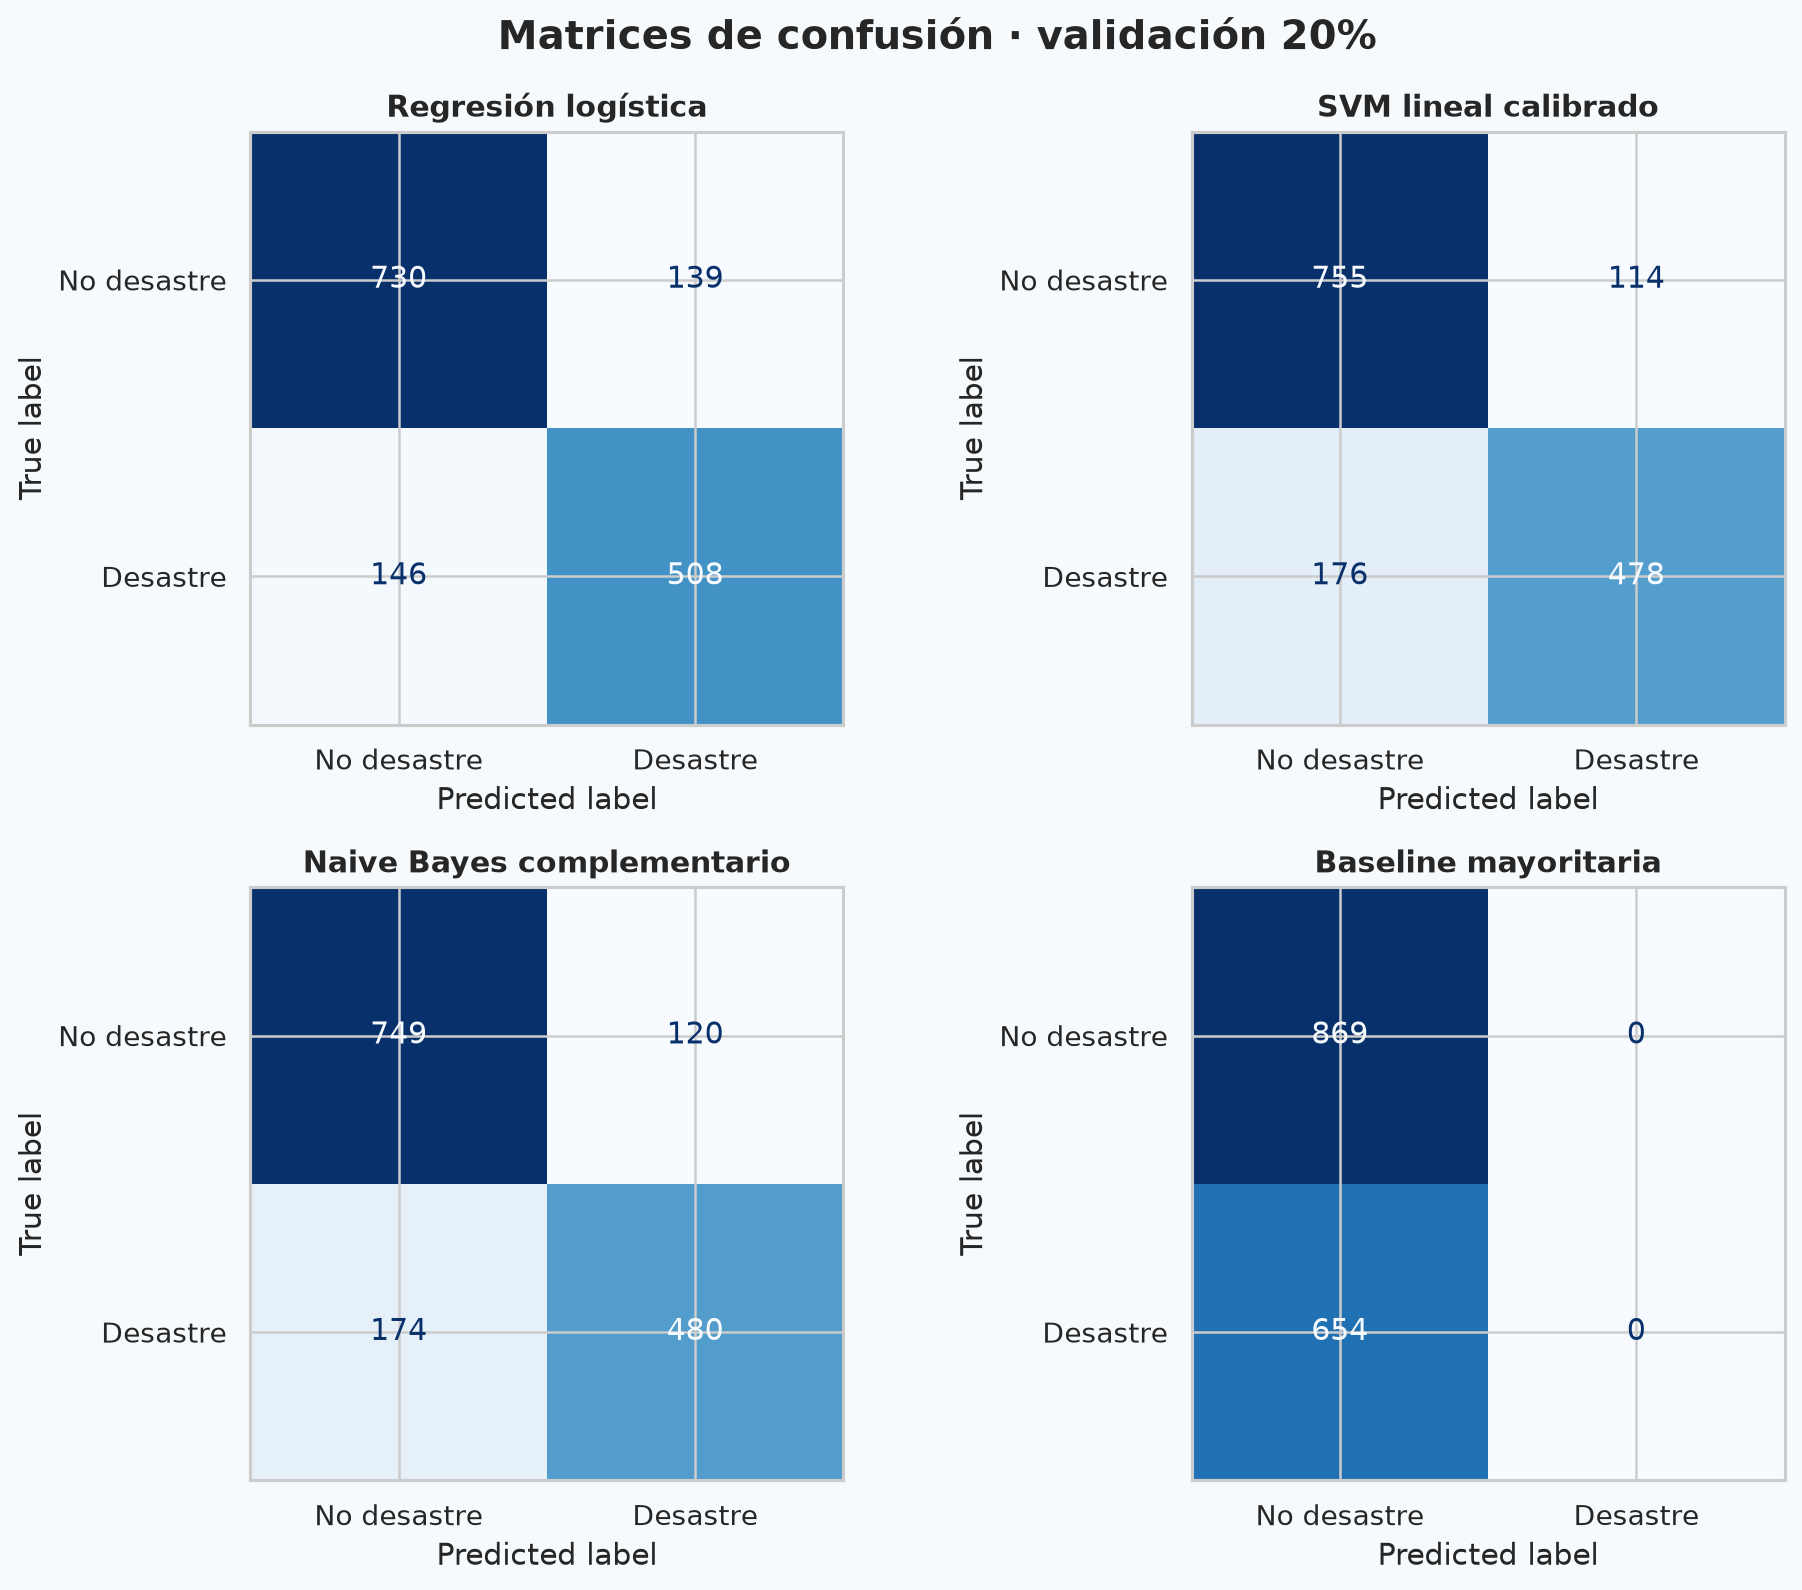

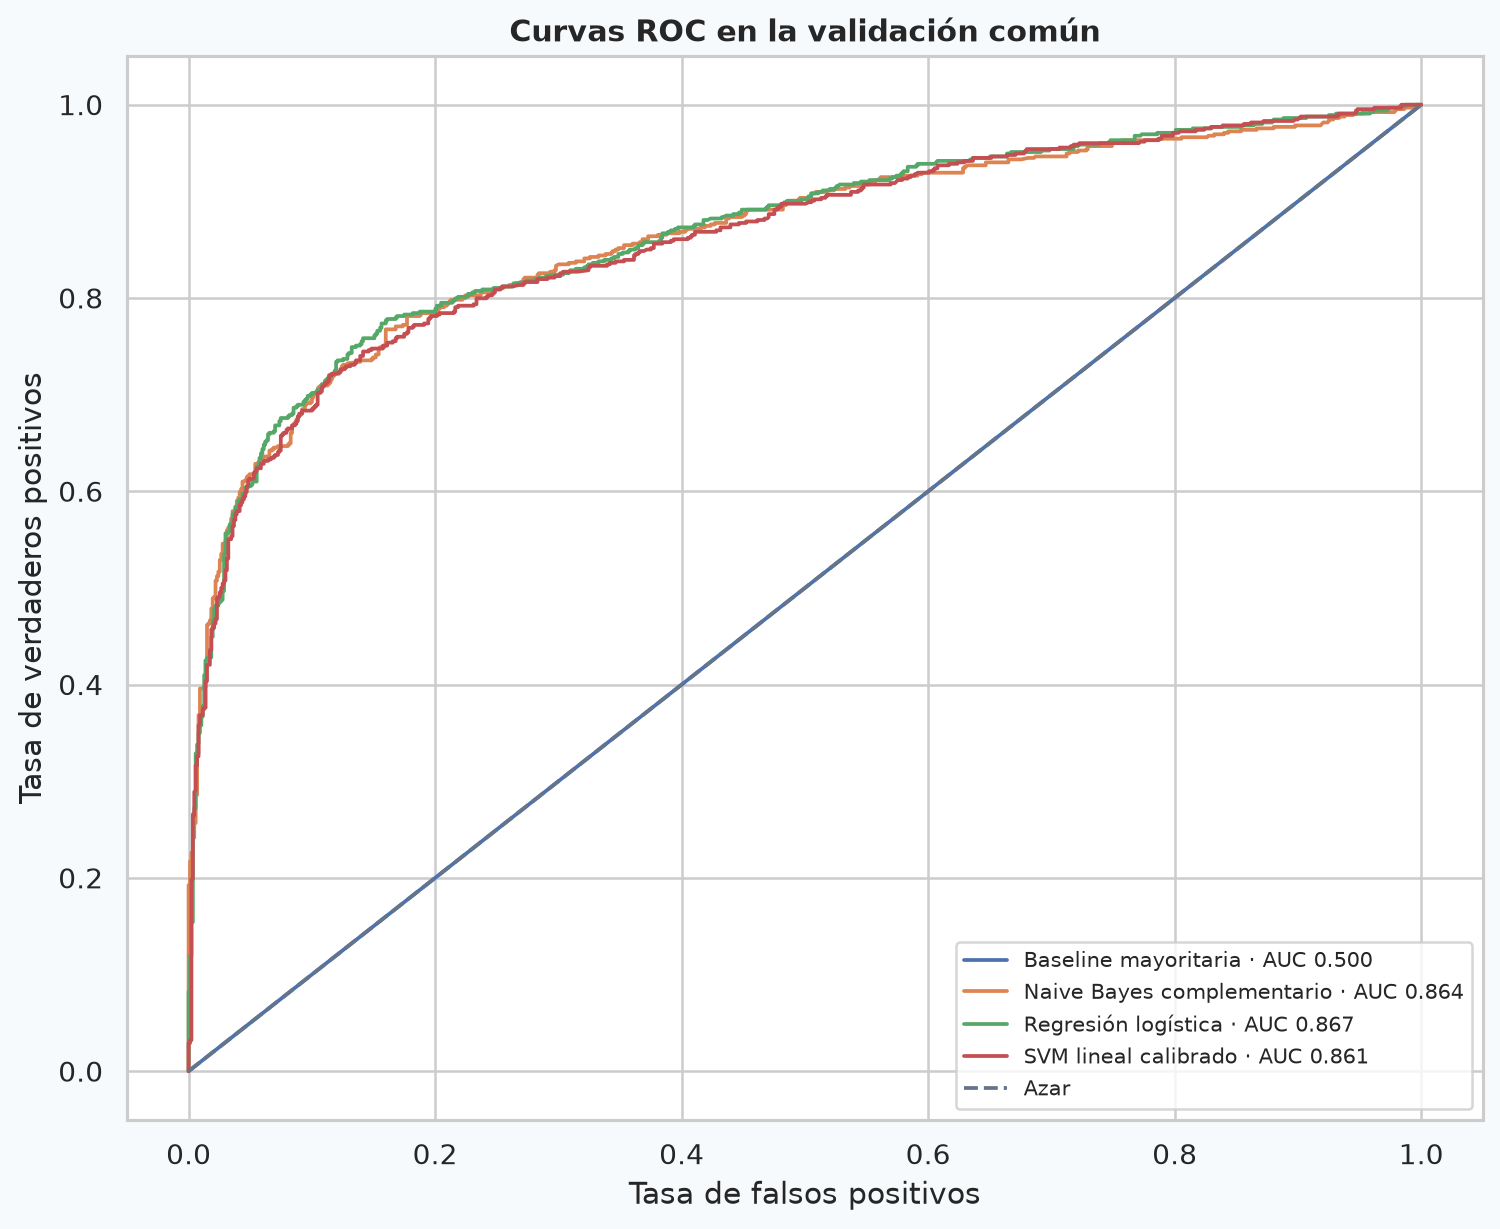

In [9]:
metrics = pd.read_csv(TABLES / "metricas_modelos_preliminares.csv")
best = metrics.iloc[0]
summary_html = (
    '<div class="metric-grid">'
    f'<div class="metric"><span>Mejor modelo</span><b style="font-size:1rem">{best["modelo"]}</b></div>'
    f'<div class="metric"><span>Exactitud</span><b>{best["accuracy"]:.2%}</b></div>'
    f'<div class="metric"><span>F1 desastre</span><b>{best["f1"]:.3f}</b></div>'
    f'<div class="metric"><span>ROC-AUC</span><b>{best["roc_auc"]:.3f}</b></div>'
    '</div>'
)
display(HTML(summary_html))
display(metrics.style.format({c: "{:.3f}" for c in ["accuracy", "precision", "recall", "f1", "f1_macro", "roc_auc"]}))
display(Image(filename=str(FIGURES / "modelos_comparacion.png"), width=1000))
display(Image(filename=str(FIGURES / "modelos_matrices_confusion.png"), width=1100))
display(Image(filename=str(FIGURES / "modelos_curvas_roc.png"), width=900))

Los cuatro modelos usan la misma división estratificada 80/20 (`random_state=42`): 6,090 observaciones para entrenamiento y 1,523 para prueba. La **regresión logística** obtiene el mejor F1 (0.781), con recall 0.777 y ROC-AUC 0.867. El SVM calibrado es ligeramente más preciso (0.807) cuando predice desastre, pero deja más falsos negativos. Esta es una selección preliminar; la afinación definitiva forma parte del 25% final.

<div class="section"><h2>6 · Función para clasificar tweets nuevos</h2></div>

In [18]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from lab5_text.modeling import predict_tweet

model = joblib.load(ROOT / "models" / "modelo_preliminar.joblib")
analyzer = SentimentIntensityAnalyzer()
samples = [
    "Massive fire near the city, residents are evacuating now!",
    "That movie was a total disaster lol 😂",
    "Emergency services report flooding on the highway.",
]
predictions = pd.DataFrame([predict_tweet(model, text, analyzer) for text in samples])
display(predictions.style.format({"probabilidad_desastre": "{:.2%}", "polaridad": "{:.3f}"}))

,texto,texto_limpio,clase,probabilidad_desastre,sentimiento,polaridad
0,"Massive fire near the city, residents are evacuating now!",massive near city residents evacuating,Desastre real,87.66%,negativo,-0.400
1,That movie was a total disaster lol 😂,movie total disaster lol,No desastre,35.27%,positivo,0.149
2,Emergency services report flooding on the highway.,emergency services report flooding highway,Desastre real,75.30%,negativo,-0.382


La función recibe **texto crudo**, aplica internamente el preprocesamiento y devuelve una clase comprensible junto con su probabilidad. El ejemplo de la película demuestra por qué la palabra *disaster* por sí sola no basta: el contexto completo disminuye la probabilidad de desastre real.

<div class="section"><h2>7 · Sentimiento exploratorio</h2></div>

,etiqueta,regla,fuente
0,positivo,compound >= 0.05,Hutto y Gilbert (2014)
1,negativo,compound <= -0.05,Hutto y Gilbert (2014)
2,neutral,-0.05 < compound < 0.05,Hutto y Gilbert (2014)


,sentiment_label,tweets,porcentaje
0,negativo,3747,49.22%
1,positivo,1971,25.89%
2,neutral,1895,24.89%


,target,sentiment_label,tweets,porcentaje,categoria
0,0,negativo,1858,42.79%,No desastre
1,0,neutral,1054,24.27%,No desastre
2,0,positivo,1430,32.93%,No desastre
3,1,negativo,1889,57.75%,Desastre real
4,1,neutral,841,25.71%,Desastre real
5,1,positivo,541,16.54%,Desastre real


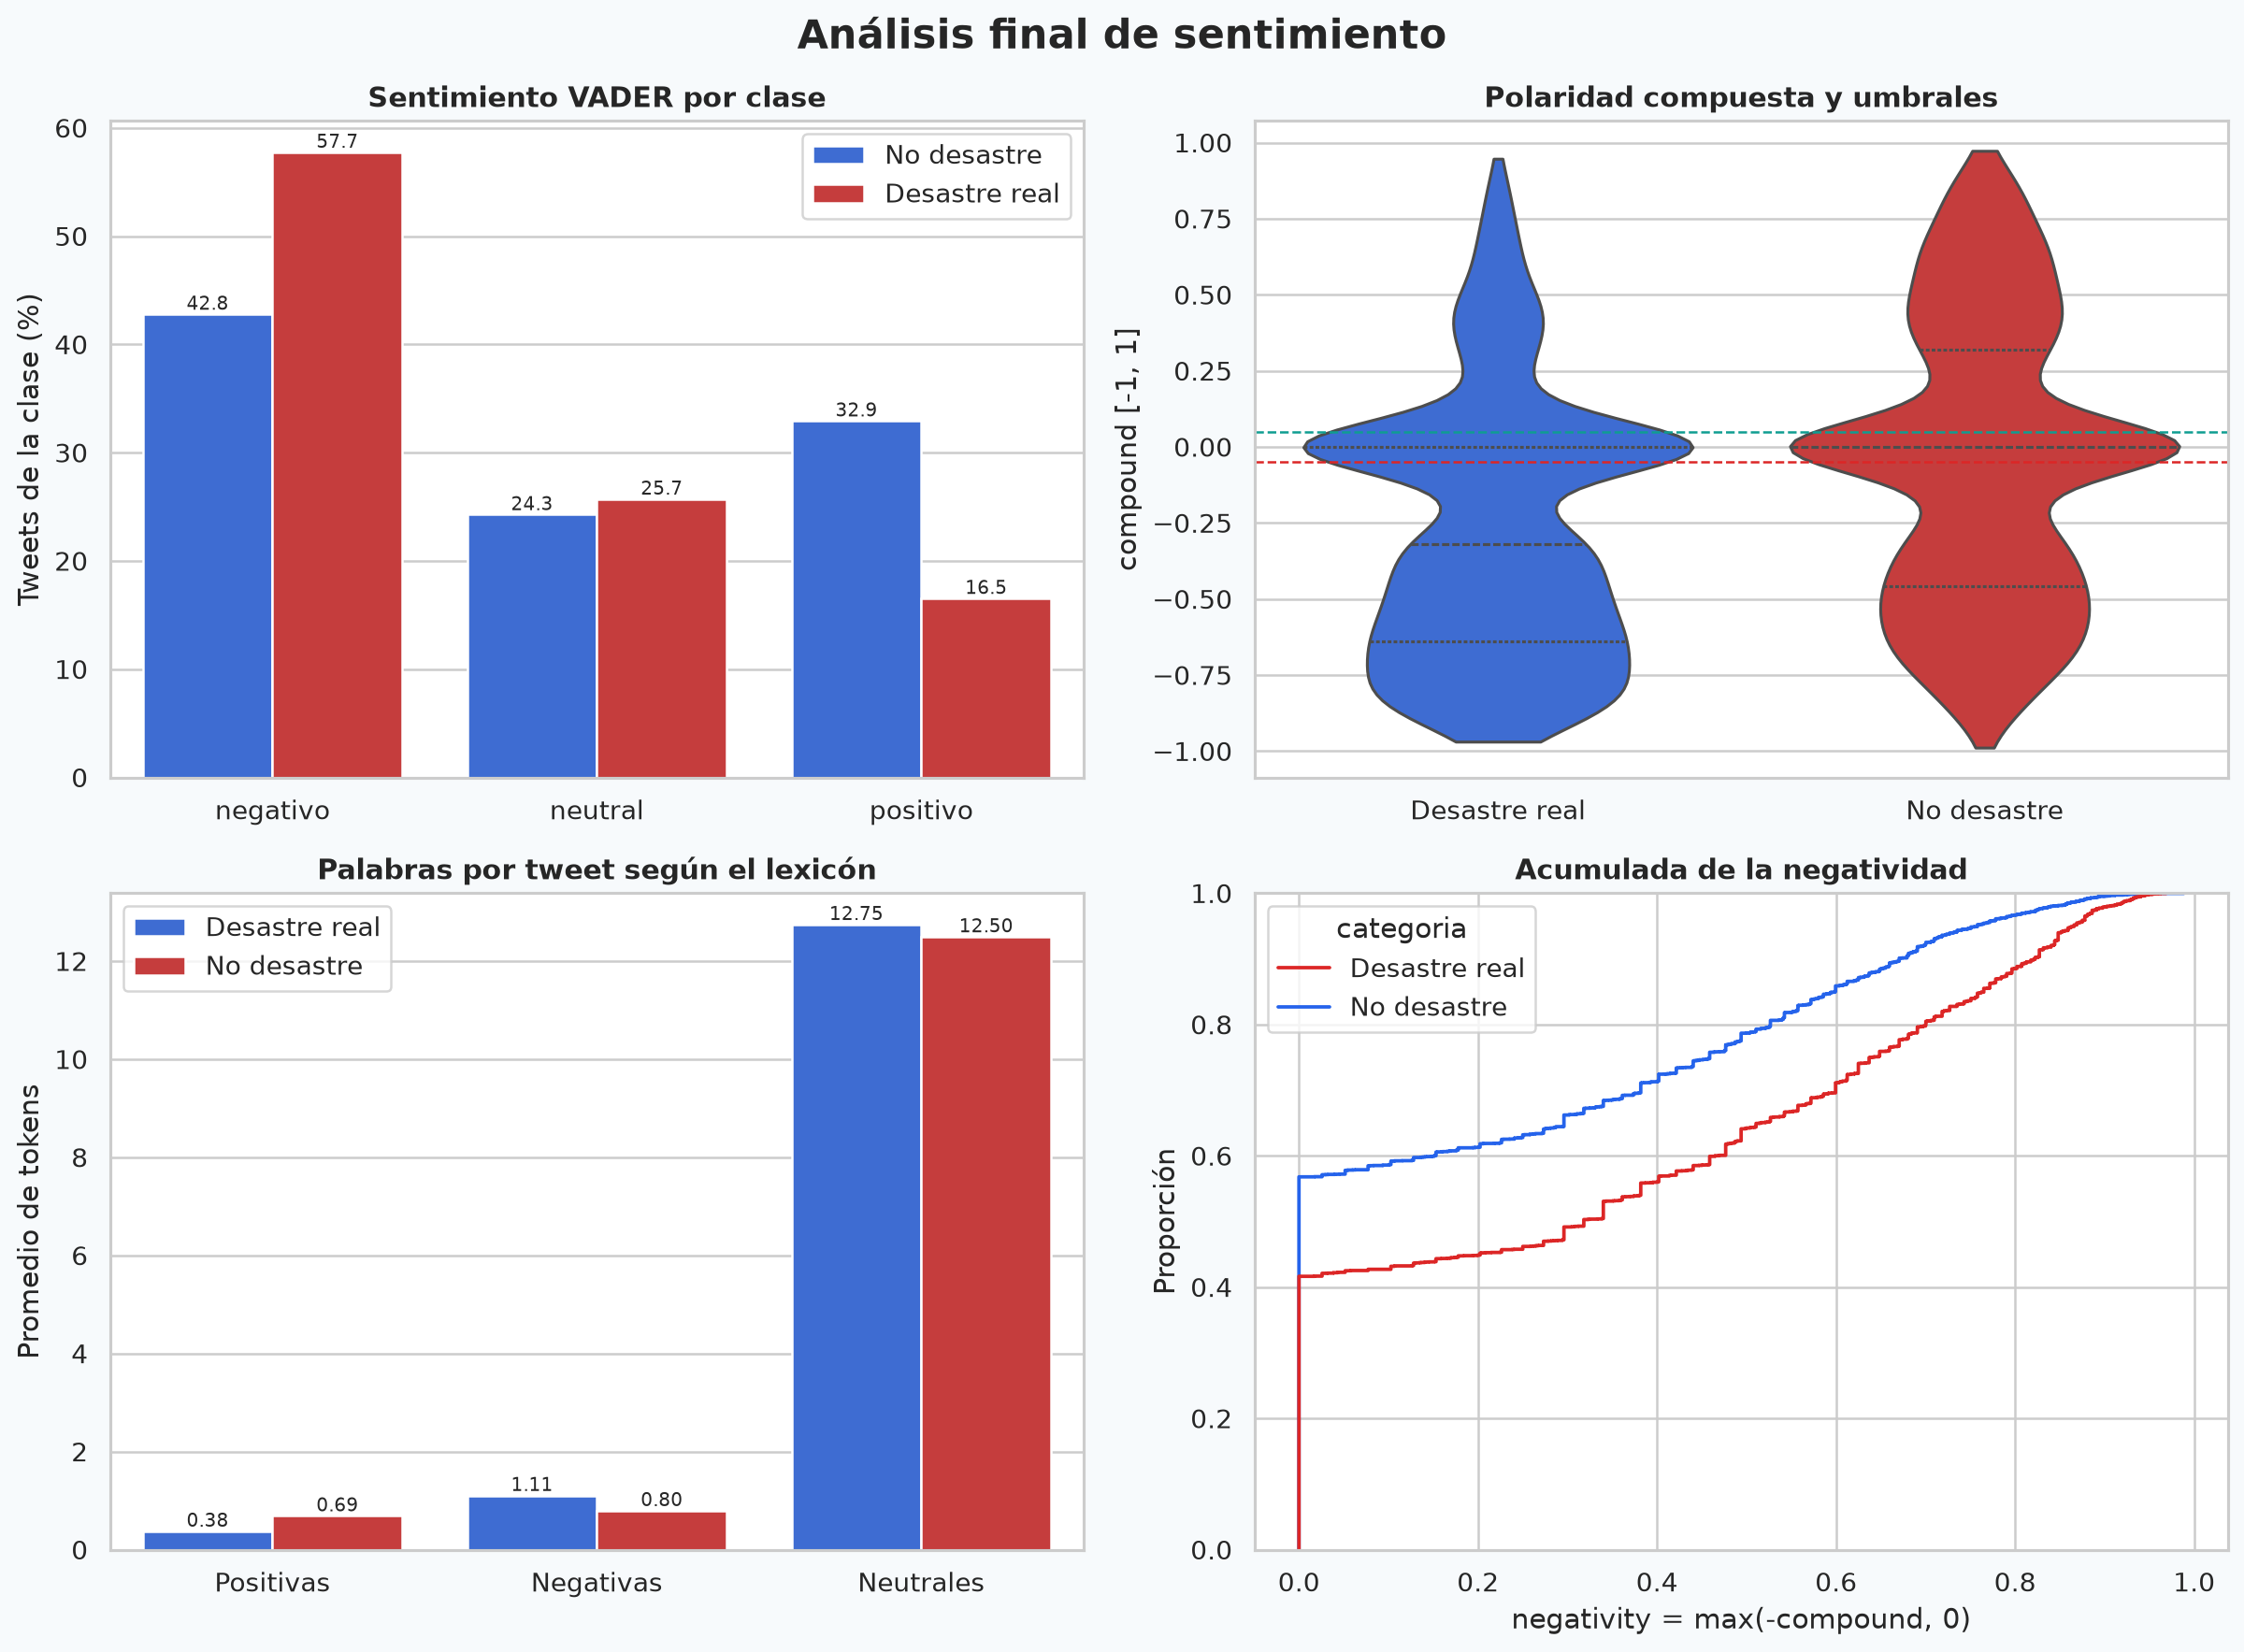

In [19]:
thresholds = pd.read_csv(TABLES / "sentimiento_umbrales.csv")
dist_global = pd.read_csv(TABLES / "sentimiento_distribucion_global.csv")
dist_clase = pd.read_csv(TABLES / "sentimiento_distribucion.csv")
display(thresholds)
display(dist_global.style.format({"porcentaje": "{:.2f}%"}))
display(dist_clase.style.format({"porcentaje": "{:.2f}%"}))
display(Image(filename=str(FIGURES / "sentimiento_final.png"), width=1050))

Del corpus completo, **49.22% de los tweets son negativos**, 25.89% positivos
y 24.89% neutros. Por clase, los tweets de desastre real son más negativos
(57.75%) y menos positivos (16.54%) que los de no desastre (42.79% negativo,
32.93% positivo) — una primera señal descriptiva que se somete a prueba formal
en la sección 12.

<div class="section"><h2>10 · Los diez tweets más positivos y más negativos</h2></div>


,id,text,categoria,sentiment_compound
0,10028,Check out 'Want Twister Tickets AND A VIP EXPE...,No desastre,0.9730
1,9345,@thoutaylorbrown I feel like accidents are jus...,No desastre,0.9564
2,8989,TodayÛªs storm will pass; let tomorrowÛªs li...,Desastre real,0.9471
3,8136,@Zak_Bagans pets r like part of the family. I ...,No desastre,0.9428
4,4541,@batfanuk we enjoyed the show today. Great fun...,No desastre,0.9423
5,4844,@batfanuk we enjoyed the show today. Great fun...,No desastre,0.9423
6,9710,Maaaaan I love Love Without Tragedy by @rihann...,No desastre,0.9394
7,8994,Free Ebay Sniping RT? http://t.co/B231Ul1O1K L...,No desastre,0.9376
8,1453,I'm not a Drake fan but I enjoy seeing him bod...,No desastre,0.9345
9,9386,@duchovbutt @Starbuck_Scully @MadMakNY @davidd...,No desastre,0.9344


,id,text,categoria,sentiment_compound
0,10689,wreck? wreck wreck wreck wreck wreck wreck wre...,No desastre,-0.9883
1,9172,@Abu_Baraa1 Suicide bomber targets Saudi mosqu...,Desastre real,-0.9686
2,9166,Suicide bomber kills 15 in Saudi security site...,Desastre real,-0.9623
3,9137,? 19th Day Since 17-Jul-2015 -- Nigeria: Suici...,Desastre real,-0.9595
4,9782,@dramaa_llama but otherwise i will stay trappe...,No desastre,-0.9556
5,9159,17 killed in SÛªArabia mosque suicide bombing...,Desastre real,-0.9552
6,4213,at the lake \r\n*sees a dead fish*\r\nme: poor...,No desastre,-0.9549
7,682,illegal alien released by Obama/DHS 4 times Ch...,Desastre real,-0.9538
8,2225,Bomb Crash Loot Riot Emergency Pipe Bomb Nucle...,Desastre real,-0.9524
9,9940,@cspan #Prez. Mr. President you are the bigges...,Desastre real,-0.9493


,extremo,categoria,tweets
0,Top 10 negativos,Desastre real,7
1,Top 10 negativos,No desastre,3
2,Top 10 positivos,Desastre real,1
3,Top 10 positivos,No desastre,9


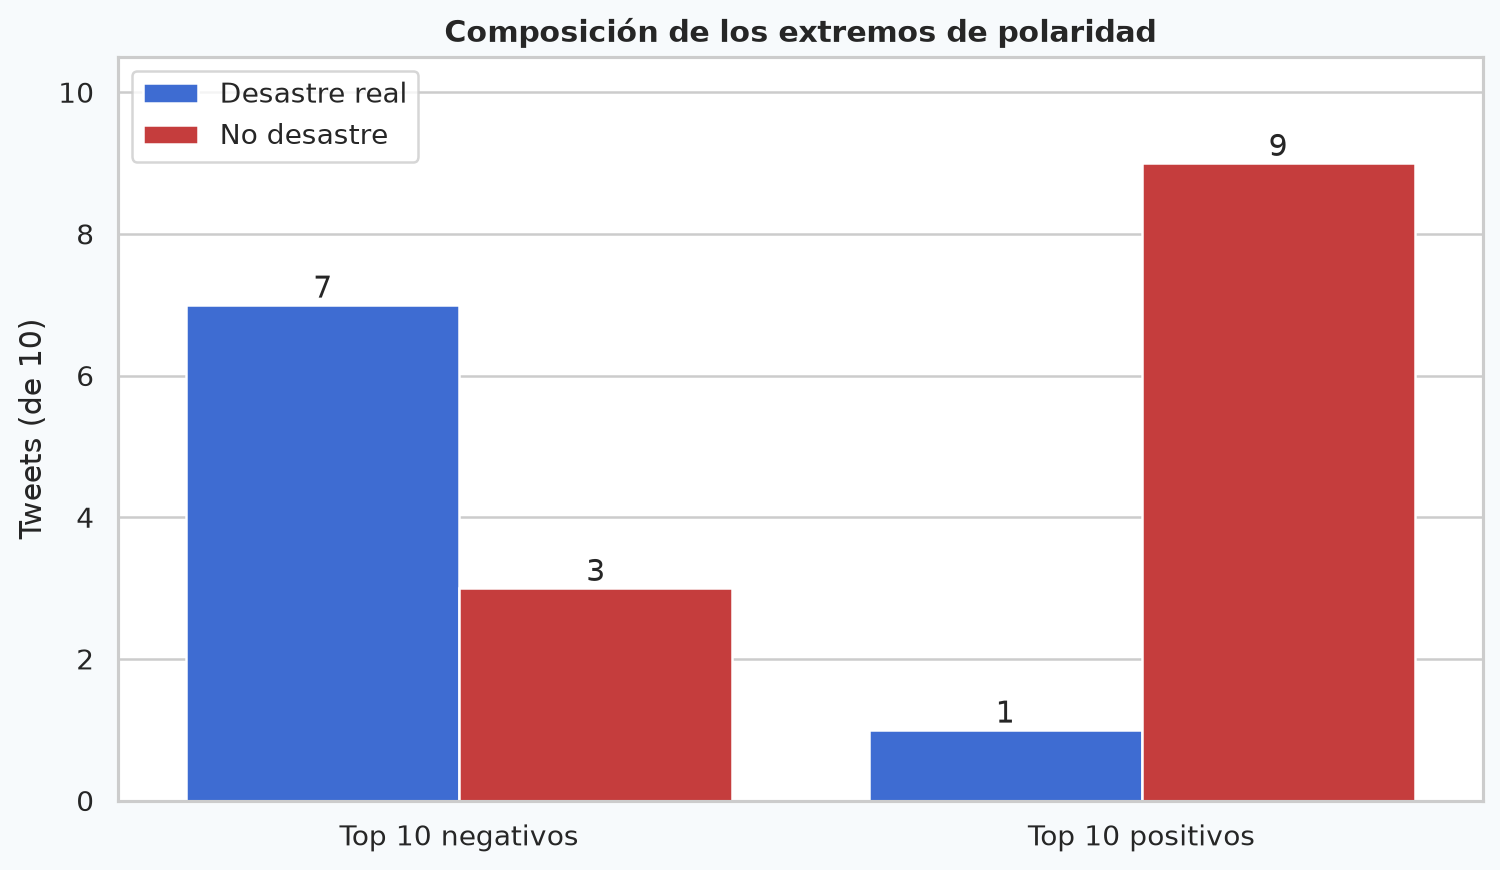

In [27]:
top_pos = pd.read_csv(TABLES / "top10_positivos.csv")
top_neg = pd.read_csv(TABLES / "top10_negativos.csv")
composicion = pd.read_csv(TABLES / "top10_composicion.csv")
display(HTML("<h3>Top 10 positivos</h3>"))
display(top_pos[["id", "text", "categoria", "sentiment_compound"]])
display(HTML("<h3>Top 10 negativos</h3>"))
display(top_neg[["id", "text", "categoria", "sentiment_compound"]])
display(HTML("<h3>Composición por categoría</h3>"))
display(composicion)
display(Image(filename=str(FIGURES / "top10_composicion.png"), width=800))

**9 de los 10 tweets más positivos son "No desastre"** (compound máximo
0.9730, id 10028); solo el id 8989 es desastre real, y usa la palabra *storm*
de forma metafórica en un mensaje de aliento (*"Today's storm will pass..."*).
**7 de los 10 tweets más negativos son "Desastre real"** (compound mínimo
−0.9883, id 10689). Casos que ilustran los límites de un léxico sin contexto:

- **id 10689** (No desastre, compound −0.9883): el texto es la palabra
  *wreck* repetida 13 veces. VADER suma valencias léxicas sin entender
  contexto: máxima negatividad sin ningún desastre real detrás.
- **id 1453** (No desastre, compound +0.9345): *"I'm not a Drake fan but I
  enjoy seeing him body-bagging people. Great marketing lol."* — lenguaje
  figurado de violencia clasificado como muy positivo por las palabras
  *enjoy* y *great*.
- **ids 4541 y 4844**: tweets duplicados con idéntico compound (0.9423),
  observación sobre la calidad del dataset más que sobre el sentimiento.
- **ids 9172, 9166, 9137, 9159**: cuatro coberturas noticiosas del mismo
  atentado en Arabia Saudita — registro periodístico, léxico denso en
  muertes, sin marcadores sociales (0 *hashtags*, 0 exclamaciones).

Estos patrones ya emergen del comportamiento léxico y sin contexto de VADER, y
motivan por qué la sección 15 concluye que la negatividad no mejora el modelo
de texto completo: la señal que aporta ya está implícita en TF-IDF y, además,
introduce este tipo de ruido.

<div class="section"><h2>11 · Contraste estadístico de sentimiento por clase</h2></div>


,metrica,n_grupo_1,n_grupo_0,media_grupo_1,media_grupo_0,mediana_grupo_1,mediana_grupo_0,diferencia_medias,diferencia_medianas,u_statistic,p_valor_bilateral,p_valor_unilateral_mayor,cliffs_delta,magnitud_efecto,ic95_dif_medias_inferior,ic95_dif_medias_superior,ic95_dif_medianas_inferior,ic95_dif_medianas_superior
0,negativity,3271,4342,0.336607,0.212570,0.3182,0.0000,0.124037,0.3182,8570308.5,1.285939e-61,6.429697e-62,0.206858,pequeño,0.109943,0.138188,0.2960,0.340
1,sentiment_negative,3271,4342,0.183193,0.137132,0.1670,0.0975,0.046061,0.0695,8229475.0,6.459491e-35,3.229745e-35,0.158862,pequeño,0.038224,0.053830,0.0565,0.087
2,sentiment_compound,3271,4342,-0.266146,-0.051510,-0.3182,0.0000,-0.214636,-0.3182,5259347.0,5.208256e-85,1.000000e+00,-0.259387,pequeño,-0.235015,-0.193970,-0.3400,-0.296


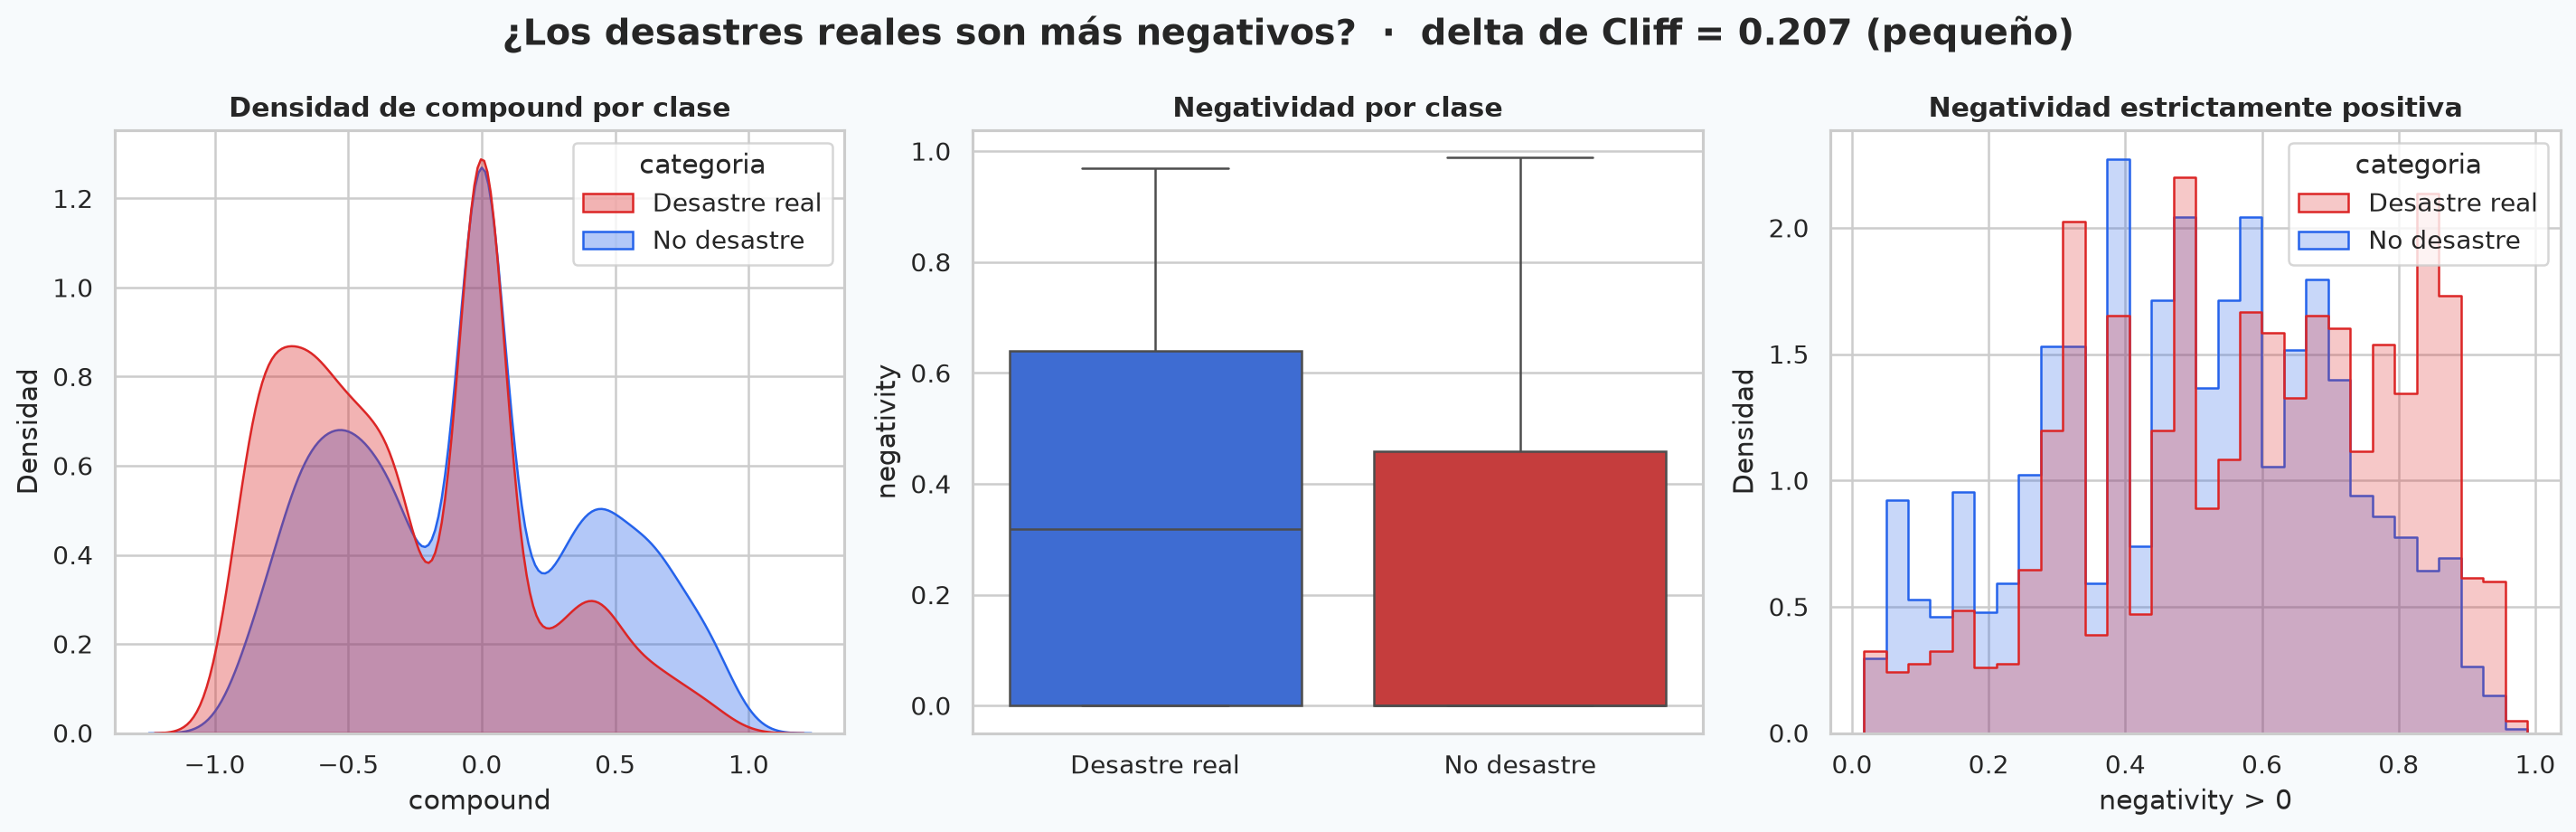

In [29]:
contraste = pd.read_csv(TABLES / "contraste_estadistico.csv")
fila = contraste[contraste["metrica"] == "negativity"].iloc[0]
display(contraste)
display(Image(filename=str(FIGURES / "contraste_negatividad.png"), width=1000))
resumen_html = (
    '<div class="metric-grid">'
    f'<div class="metric"><span>U de Mann-Whitney</span><b style="font-size:1rem">{fila["u_statistic"]:.0f}</b></div>'
    f'<div class="metric"><span>p (unilateral)</span><b style="font-size:0.85rem">{fila["p_valor_unilateral_mayor"]:.3e}</b></div>'
    f'<div class="metric"><span>Delta de Cliff</span><b>{fila["cliffs_delta"]:.4f}</b></div>'
    f'<div class="metric"><span>Magnitud</span><b style="font-size:1rem">{fila["magnitud_efecto"]}</b></div>'
    '</div>'
)
display(HTML(resumen_html))

<div class="answer"><b>Respuesta.</b> Sí: los tweets de desastre real
(media de negatividad 0.3366, mediana 0.3182, n=3,271) son más negativos que
los de no desastre (media 0.2126, mediana 0.0000, n=4,342). La diferencia es
**estadísticamente muy sólida** (U = 8,570,308.5; p unilateral ≈ 6.43 × 10⁻⁶²)
pero el **tamaño de efecto es pequeño** (delta de Cliff = 0.2069, cortes de
Romano et al., 2006). El intervalo bootstrap al 95% de la diferencia de medias
es [0.1099, 0.1382]. Es una asociación observacional, no causal, y el p tan
pequeño refleja sobre todo el tamaño de la muestra: el delta de Cliff pequeño
indica que las distribuciones se solapan mucho, así que la negatividad por sí
sola no separa perfectamente las dos clases.</div>

<div class="section"><h2>12 · Variable de negatividad</h2></div>

In [30]:
definicion = pd.read_csv(TABLES / "negatividad_definicion.csv")
rangos = pd.read_csv(TABLES / "negatividad_por_rango.csv")
display(definicion)
display(rangos.style.format({"porcentaje": "{:.2f}%"}))

,indicador,valor
0,definicion,"negativity = max(-compound, 0)"
1,rango_teorico,"[0, 1]"
2,minimo_observado,0.0
3,maximo_observado,0.9883
4,media,0.2658632339419414
5,mediana,0.0
6,desviacion,0.3102200624712078
7,tweets_con_negatividad_cero,3828
8,pct_negatividad_cero,50.28241166425851
9,correlacion_spearman_con_neg_vader,0.8937114637684926


,rango,categoria,tweets,porcentaje
0,"(-0.001, 0.0]",Desastre real,1362,41.64%
1,"(-0.001, 0.0]",No desastre,2466,56.79%
2,"(0.0, 0.2]",Desastre real,105,3.21%
3,"(0.0, 0.2]",No desastre,195,4.49%
4,"(0.2, 0.4]",Desastre real,364,11.13%
5,"(0.2, 0.4]",No desastre,434,10.00%
6,"(0.4, 0.6]",Desastre real,495,15.13%
7,"(0.4, 0.6]",No desastre,634,14.60%
8,"(0.6, 0.8]",Desastre real,570,17.43%
9,"(0.6, 0.8]",No desastre,469,10.80%


Se define `negativity = max(-compound, 0)`, acotada en `[0, 1]`: vale 0 para
tweets neutros o positivos y crece con la negatividad del `compound` de VADER.
En el corpus toma valores en `[0.0000, 0.9883]`, con media 0.2659, mediana
0.0000 y desviación estándar 0.3102; **50.28% de los tweets tienen
negatividad exactamente 0**. Su correlación de Spearman con la componente
`neg` de VADER es 0.8937 (coherente, redundante por diseño) y con `target` es
apenas 0.1898 — una pista temprana de que aporta poca señal nueva para la
clasificación.

<div class="section"><h2>13 · Reentrenamiento con la variable de negatividad</h2></div>


,modelo,accuracy,precision,recall,f1,f1_macro,roc_auc,tn,fp,fn,tp,n_train,n_test,usa_negatividad
0,A · TF-IDF sin negatividad,0.8129,0.7852,0.7768,0.7809,0.8088,0.8666,730,139,146,508,6090,1523,False
1,B · TF-IDF con negatividad,0.7978,0.7662,0.7615,0.7638,0.7935,0.8670,717,152,156,498,6090,1523,True


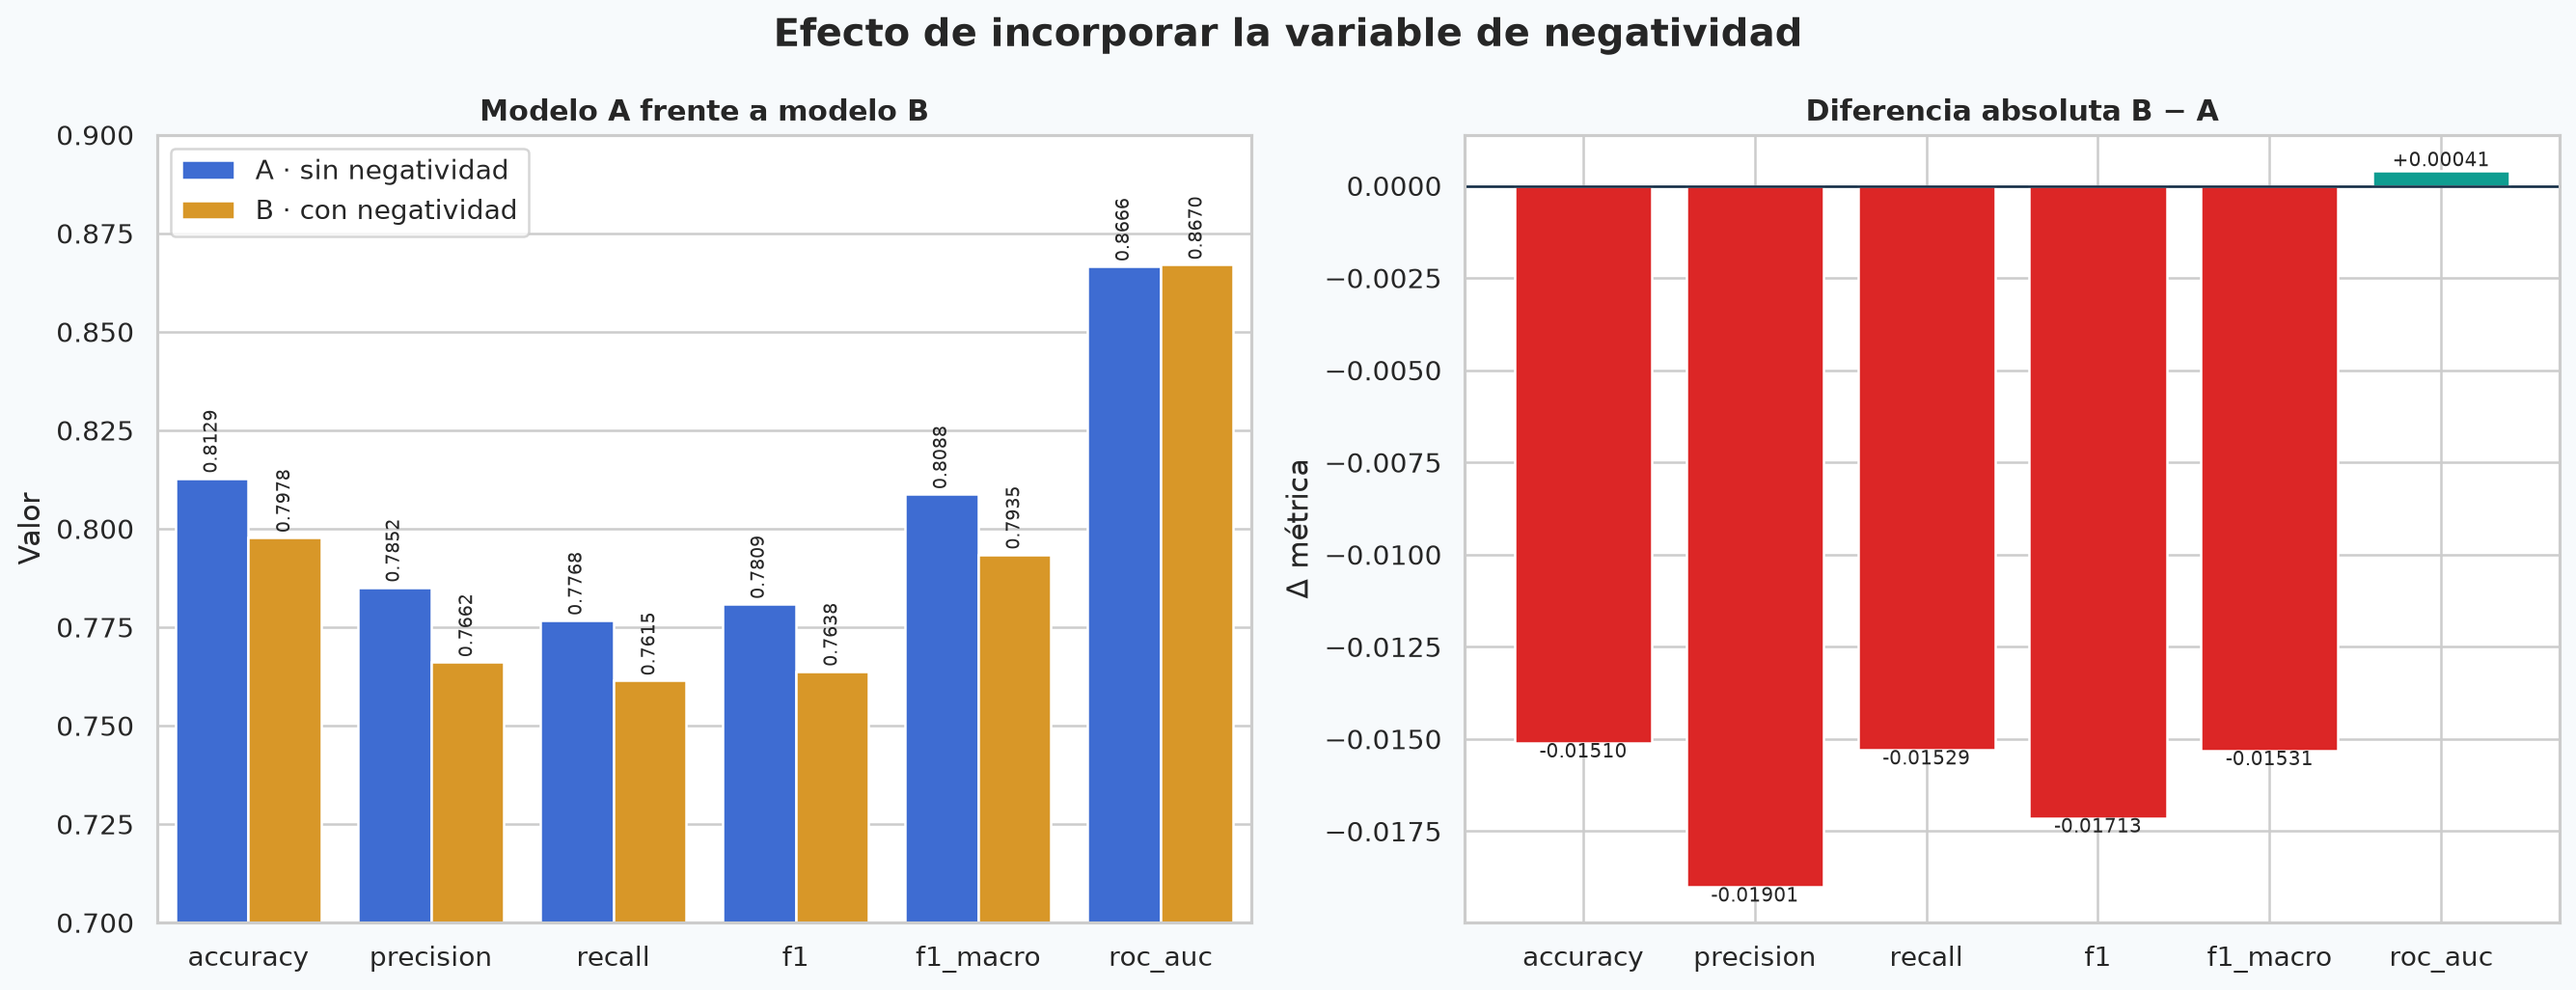

In [31]:
comparacion = pd.read_csv(TABLES / "comparacion_negatividad_metricas.csv")
display(comparacion.style.format({c: "{:.4f}" for c in ["accuracy", "precision", "recall", "f1", "f1_macro", "roc_auc"]}))
display(Image(filename=str(FIGURES / "comparacion_negatividad.png"), width=1000))

<div class="section"><h2>14 · Comparación cuantificada</h2></div>

In [32]:
diferencias = pd.read_csv(TABLES / "comparacion_negatividad_diferencias.csv")
display(diferencias.style.format({
    "modelo_a_sin_negatividad": "{:.4f}",
    "modelo_b_con_negatividad": "{:.4f}",
    "diferencia_absoluta": "{:.4f}",
}))

,metrica,modelo_a_sin_negatividad,modelo_b_con_negatividad,diferencia_absoluta,sentido
0,accuracy,0.8129,0.7978,-0.0151,empeora
1,precision,0.7852,0.7662,-0.0190,empeora
2,recall,0.7768,0.7615,-0.0153,empeora
3,f1,0.7809,0.7638,-0.0171,empeora
4,f1_macro,0.8088,0.7935,-0.0153,empeora
5,roc_auc,0.8666,0.8670,0.0004,mejora
6,tn,730.0000,717.0000,-13.0000,empeora
7,fp,139.0000,152.0000,13.0000,empeora
8,fn,146.0000,156.0000,10.0000,empeora
9,tp,508.0000,498.0000,-10.0000,empeora


<div class="answer"><b>¿La inclusión de <code>negativity</code> mejoró el
modelo? No.</b> Empeoró en 9 de las 10 métricas comparadas. El F1 de la clase
desastre cae de 0.780938 a 0.763804 (**−0.017134**, −2.19% relativo) y la
exactitud cae de 0.812869 a 0.797768 (**−0.015102**). Aparecen 13 falsos
positivos y 10 falsos negativos adicionales (de 1,523 casos de validación). La
única métrica que mejora es el ROC-AUC, en **+0.000408** (+0.05% relativo) —
una mejora de cuarto decimal en una métrica de ordenamiento, frente a un
deterioro dos órdenes de magnitud mayor en la métrica que prioriza la
rúbrica. La explicación más plausible: `negativity` ya está implícita en el
texto que TF-IDF modela (correlación de Spearman con `target` de solo 0.19),
así que aporta redundancia y ruido en vez de señal nueva. Esta diferencia
**no justifica agregar la variable** al modelo de producción.</div>